# Introduction to text embeddings on S&P 500 news
### Course Project — Part 1, Section A

**Pipeline:** S&P 500 tickers → `yfinance` news → structured DataFrame → `all-MiniLM-L6-v2`
embeddings → K-Means clustering → silhouette-based choice of *k* → PCA visualisation →
interpretation of the clusters.

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Retrieve Financial News:**
   - Use the `yfinance` library to gather news headlines for all companies in the S&P 500 index.

2. **Clean and Structure Financial Text Data:**
   - Extract and organize relevant metadata (e.g., ticker, title, summary, publication date, URL) into a structured pandas DataFrame.

3. **Generate Text Embeddings:**
   - Apply a pre-trained sentence transformer model (`all-MiniLM-L6-v2`) to convert news headlines and summaries into numerical embeddings.

4. **Apply Clustering Techniques:**
   - Use K-Means clustering to identify groups of similar news articles based on semantic content.

5. **Determine Optimal Number of Clusters:**
   - Evaluate clustering quality using silhouette scores to find the best number of clusters.

6. **Visualize High-Dimensional Embeddings:**
   - Reduce the embedding space using PCA and visualize clusters in two dimensions.

7. **Interpret Cluster Themes:**
   - Analyze representative news headlines of every cluster and give each group a business-readable label.

## Install and Import important librairies

In [1]:
%pip install --quiet pandas numpy yfinance lxml matplotlib scikit-learn
%pip install --quiet -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 15.1 MB/s eta 0:00:00


In [2]:
%pip install --quiet yellowbrick

In [3]:
import io
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from IPython.display import Markdown, display
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_samples, silhouette_score)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas", pd.__version__, "| numpy", np.__version__, "| yfinance", yf.__version__)

pandas 2.2.2 | numpy 2.0.2 | yfinance 0.2.66


## Get the list of stocks in the S&P 500

### Loading the ticker list robustly

`pd.read_html(url)` on its own returns **HTTP 403**: Wikipedia rejects the default `urllib`
User-Agent that pandas sends. The loader below fetches the page with `requests` and an explicit
User-Agent, retries with a second one, and falls back to a static CSV mirror if Wikipedia is
unreachable altogether — so a blocked request cannot stop the notebook at its first data step.

In [4]:
SP500_WIKI = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
SP500_BACKUP = ('https://raw.githubusercontent.com/datasets/'
                's-and-p-500-companies/main/data/constituents.csv')


def get_sp500_table(timeout=30):
    """Return the S&P 500 constituents table as a DataFrame.

    `pd.read_html(url)` alone fails with HTTP 403: Wikipedia rejects the default urllib
    User-Agent. We therefore fetch the page with `requests` and an explicit User-Agent, and
    fall back to a static CSV mirror if Wikipedia is unreachable.
    """
    agents = [
        'SP500-CourseProject/1.0 (educational use; contact: student@example.com)',
        ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
         '(KHTML, like Gecko) Chrome/122.0 Safari/537.36'),
    ]
    for agent in agents:
        try:
            response = requests.get(SP500_WIKI, headers={'User-Agent': agent}, timeout=timeout)
            response.raise_for_status()
            # StringIO: passing raw HTML straight to read_html is deprecated in pandas >= 2.1
            table = pd.read_html(io.StringIO(response.text))[0]
            if 'Symbol' in table.columns and len(table) > 400:
                print(f"Tickers loaded from Wikipedia ({len(table)} rows).")
                return table
        except Exception as exc:
            print(f"  Wikipedia attempt failed ({type(exc).__name__}: {exc}) - retrying...")

    print("  Falling back to the static CSV mirror...")
    table = pd.read_csv(SP500_BACKUP)
    table = table.rename(columns={'Name': 'Security', 'Sector': 'GICS Sector'})
    print(f"Tickers loaded from the backup mirror ({len(table)} rows).")
    return table


# Read and print the stock tickers that make up S&P500
df_tickers = get_sp500_table()
display(df_tickers.head())

Tickers loaded from Wikipedia (503 rows).


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [5]:
ticker_list = df_tickers['Symbol'].tolist()

In [6]:
# Yahoo Finance uses '-' instead of '.' for share classes (BRK.B -> BRK-B)
yahoo_symbols = [t.strip().replace('.', '-') for t in ticker_list]

# Company / sector metadata: used later to check whether the clusters are just sector groupings
meta = (df_tickers.assign(YAHOO_SYMBOL=yahoo_symbols)
                  .set_index('YAHOO_SYMBOL')[['Security', 'GICS Sector']]
                  .rename(columns={'Security': 'COMPANY', 'GICS Sector': 'SECTOR'}))

print(f"S&P 500 constituents: {len(yahoo_symbols)}")
display(meta.head())

S&P 500 constituents: 503


,COMPANY,SECTOR
YAHOO_SYMBOL,,
MMM,3M,Industrials
AOS,A. O. Smith,Industrials
ABT,Abbott Laboratories,Health Care
ABBV,AbbVie,Health Care
ACN,Accenture,Information Technology


## Get the news of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the news of all 500 stocks in the index.
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

### Get the news in a dictionary

The `.news` endpoint is queried once per ticker, so this loop makes ~500 HTTP calls. Three
precautions keep it robust:

* every call is wrapped in a `try/except` — a single failing ticker must not kill the whole loop;
* a short pause between calls avoids being throttled by Yahoo;
* newer `yfinance` releases expose `get_news(count=…)` while older ones only expose the `.news`
  property, so we support both.

Expect a non-trivial number of tickers to return an empty list: not every S&P 500 company has news
attached on a given day.

In [7]:
def fetch_news(symbol, count=10, pause=0.15):
    """Return the raw list of news items for one ticker (empty list on failure)."""
    try:
        ticker = yf.Ticker(symbol)
        try:
            items = ticker.get_news(count=count)          # yfinance >= 0.2.5x
        except TypeError:
            items = ticker.news                           # older releases
        return items or []
    except Exception as exc:
        print(f"  [warn] {symbol}: {type(exc).__name__} - {exc}")
        return []
    finally:
        time.sleep(pause)


# Dictionary: key = ticker symbol, value = raw news payload returned by yfinance
news_dict = {}
t0 = time.time()
for i, symbol in enumerate(yahoo_symbols, start=1):
    news_dict[symbol] = fetch_news(symbol)
    if i % 50 == 0:
        collected = sum(len(v) for v in news_dict.values())
        print(f"  {i:>3}/{len(yahoo_symbols)} tickers | {collected} articles | "
              f"{time.time() - t0:.0f}s elapsed")

n_articles = sum(len(v) for v in news_dict.values())
n_empty = sum(1 for v in news_dict.values() if not v)
print(f"\nTickers queried      : {len(news_dict)}")
print(f"Tickers with no news : {n_empty}")
print(f"Raw articles collected: {n_articles}")

   50/503 tickers | 500 articles | 14s elapsed
  100/503 tickers | 1000 articles | 28s elapsed
  150/503 tickers | 1500 articles | 42s elapsed
  200/503 tickers | 2000 articles | 56s elapsed
  250/503 tickers | 2500 articles | 69s elapsed
  300/503 tickers | 3000 articles | 83s elapsed
  350/503 tickers | 3500 articles | 96s elapsed
  400/503 tickers | 4000 articles | 110s elapsed
  450/503 tickers | 4500 articles | 124s elapsed
  500/503 tickers | 5000 articles | 137s elapsed

Tickers queried      : 503
Tickers with no news : 0
Raw articles collected: 5030


In [8]:
# What does one raw item actually look like? (useful to know which keys to extract)
sample_symbol = next(s for s, v in news_dict.items() if v)
sample_item = news_dict[sample_symbol][0]
print("Sample ticker:", sample_symbol)
print("Top-level keys:", list(sample_item.keys()))
if 'content' in sample_item:
    print("content keys :", list(sample_item['content'].keys()))
sample_item

Sample ticker: MMM
Top-level keys: ['id', 'content']
content keys : ['id', 'contentType', 'title', 'description', 'summary', 'pubDate', 'displayTime', 'isHosted', 'bypassModal', 'previewUrl', 'thumbnail', 'provider', 'canonicalUrl', 'clickThroughUrl', 'metadata', 'finance', 'storyline']


{'id': 'ddb17a1d-4ff6-3705-a55b-64606e58675b',
 'content': {'id': 'ddb17a1d-4ff6-3705-a55b-64606e58675b',
  'contentType': 'STORY',
  'title': 'Industrial Giant Sees Insider Selling, According to Latest SEC Filing',
  'description': '',
  'summary': 'Kevin H. Rhodes exercised options at $154.69 per share and immediately liquidated the position in open market trading, reducing his direct equity stake by 15%.',
  'pubDate': '2026-07-31T22:40:01Z',
  'displayTime': '2026-07-31T22:40:01Z',
  'isHosted': True,
  'bypassModal': False,
  'previewUrl': None,
  'thumbnail': {'originalUrl': 'https://media.zenfs.com/en/motleyfool.com/5a440778ac8f2b72736c872664e8a572',
   'originalWidth': 800,
   'originalHeight': 714,
   'caption': '',
   'resolutions': [{'url': 'https://s.yimg.com/uu/api/res/1.2/Z.2h1QPR_hfwjCgv_xQ4Bw--~B/aD03MTQ7dz04MDA7YXBwaWQ9eXRhY2h5b24-/https://media.zenfs.com/en/motleyfool.com/5a440778ac8f2b72736c872664e8a572',
     'width': 800,
     'height': 714,
     'tag': 'original'}

### Structure the news into a pandas dataframe

Your final dataframe should have the following columns:
- TICKER
- TITLE (of the news)
- SUMMARY (of the news)
- PUBLICATION_DATE (of the news)
- URL (of the news)

Note: all of those fields are provided in the yfinance news component. Refer to the library documentation.

**Two payload schemas.** Recent `yfinance` versions nest everything under `content`
(`content.title`, `content.summary`, `content.pubDate`, `content.canonicalUrl.url`,
`content.provider.displayName`), while older versions return a flat dictionary
(`title`, `publisher`, `link`, `providerPublishTime` as a UNIX timestamp). The parser below handles
both so the notebook does not break when the library is upgraded.

In [9]:
def _first(dct, *keys):
    """Return the first non-empty value among `keys`."""
    for k in keys:
        value = dct.get(k)
        if value:
            return value
    return None


def parse_article(symbol, item):
    """Flatten one raw yfinance news item into a record with the required columns."""
    content = item.get('content', item)                   # new schema nests under 'content'

    title = _first(content, 'title', 'headline')
    summary = _first(content, 'summary', 'description', 'shortDescription')

    # URL: new schema -> canonicalUrl/clickThroughUrl dicts; old schema -> 'link'
    url = None
    for key in ('canonicalUrl', 'clickThroughUrl'):
        node = content.get(key)
        if isinstance(node, dict) and node.get('url'):
            url = node['url']
            break
    url = url or _first(content, 'link', 'url')

    # Provider: new schema -> provider.displayName; old schema -> 'publisher'
    provider = content.get('provider')
    provider = provider.get('displayName') if isinstance(provider, dict) else provider
    provider = provider or _first(content, 'publisher', 'providerDisplayName')

    published = _first(content, 'pubDate', 'displayTime', 'providerPublishTime')

    return {
        'TICKER': symbol,
        'TITLE': title,
        'SUMMARY': summary,
        'PUBLICATION_DATE': published,
        'URL': url,
        'PROVIDER': provider,
        'ARTICLE_ID': item.get('id') or _first(content, 'id', 'uuid'),
    }


records = [parse_article(symbol, item)
           for symbol, items in news_dict.items()
           for item in items]

df_news_raw = pd.DataFrame(records)
print(f"Raw news DataFrame: {df_news_raw.shape[0]} rows x {df_news_raw.shape[1]} columns")
display(df_news_raw.head())

Raw news DataFrame: 5030 rows x 7 columns


,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,PROVIDER,ARTICLE_ID
0,MMM,"Industrial Giant Sees Insider Selling, According to Latest SEC Filing",Kevin H. Rhodes exercised options at $154.69 per share and immediately liquidated the ...,2026-07-31T22:40:01Z,https://www.fool.com/coverage/filings/2026/07/31/industrial-giant-sees-insider-selling...,Motley Fool,ddb17a1d-4ff6-3705-a55b-64606e58675b
1,MMM,"CSL Q2 Earnings Beat Estimates on Record Sales, Outlook Raised","Carlisle tops Q2 earnings and revenue estimates, posts record sales and raises its 202...",2026-07-30T15:38:00Z,https://finance.yahoo.com/markets/stocks/articles/csl-q2-earnings-beat-estimates-15380...,Zacks,381e1cf1-30a9-378b-9482-050124f86b2b
2,MMM,Five Below and Whirlpool have been highlighted as Zacks Bull and Bear of the Day,"Five Below delivered strong sales growth and raised guidance, while Whirlpool faced we...",2026-07-30T12:48:00Z,https://finance.yahoo.com/markets/stocks/articles/five-below-whirlpool-highlighted-zac...,Zacks,02301a68-4096-3afb-b45d-1d45d1b12094
3,MMM,Buy These 3 Blue-Chip Stocks After Strong Q2 2026 Earnings Results,"MMM, TRV and UNH posted strong Q2 results, with higher guidance, investment strength a...",2026-07-29T13:06:00Z,https://finance.yahoo.com/markets/stocks/articles/buy-3-blue-chip-stocks-130600697.html,Zacks,706ffa62-987f-32e0-89ff-7656c0a28d11
4,MMM,"Beat the Market Like Zacks: Monster Beverage, Carpenter Tech, Usio in Focus","MNST, CRS and USIO highlight Zacks strategies that outperformed amid a volatile market.",2026-07-27T12:15:00Z,https://finance.yahoo.com/markets/stocks/articles/beat-market-zacks-monster-beverage-1...,Zacks,0e207be0-b3b5-3cd7-a7d7-12aec046738b


In [10]:
# --- Cleaning ---------------------------------------------------------------------------------
df_news = df_news_raw.copy()
before = len(df_news)

# 1. Publication date -> timezone-aware datetime (epoch seconds in the legacy schema)
def to_datetime(value):
    if pd.isna(value):
        return pd.NaT
    if isinstance(value, (int, float)) or (isinstance(value, str) and str(value).isdigit()):
        return pd.to_datetime(float(value), unit='s', utc=True)
    return pd.to_datetime(value, utc=True, errors='coerce')

df_news['PUBLICATION_DATE'] = df_news['PUBLICATION_DATE'].apply(to_datetime)

# 2. Normalise the text fields
for col in ['TITLE', 'SUMMARY', 'PROVIDER']:
    df_news[col] = (df_news[col].astype('string')
                                .str.replace(r'\s+', ' ', regex=True)
                                .str.strip())

# 3. A row without a title is unusable (the title is what we embed)
df_news = df_news[df_news['TITLE'].notna() & (df_news['TITLE'].str.len() >= 10)]

# 4. Drop duplicates: the same article is often attached to several tickers
df_news = df_news.drop_duplicates(subset=['TICKER', 'TITLE'])

# 5. Missing summaries: keep the row, flag it, and fall back to the title
df_news['HAS_SUMMARY'] = df_news['SUMMARY'].notna()
df_news['SUMMARY'] = df_news['SUMMARY'].fillna(df_news['TITLE'])

df_news = (df_news.sort_values(['TICKER', 'PUBLICATION_DATE'], ascending=[True, False])
                  .reset_index(drop=True))

print(f"Rows before cleaning : {before}")
print(f"Rows after cleaning  : {len(df_news)}")
print(f"Unique tickers       : {df_news['TICKER'].nunique()}")
print(f"Articles per ticker  : mean {len(df_news) / df_news['TICKER'].nunique():.1f}")
print(f"Rows without a real summary: {(~df_news['HAS_SUMMARY']).sum()}")

Rows before cleaning : 5030
Rows after cleaning  : 5030
Unique tickers       : 503
Articles per ticker  : mean 10.0
Rows without a real summary: 0


In [11]:
df_news = df_news[['TICKER', 'TITLE', 'SUMMARY', 'PUBLICATION_DATE', 'URL', 'PROVIDER',
                   'ARTICLE_ID', 'HAS_SUMMARY']]
display(df_news.head(10))
df_news.info()

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,PROVIDER,ARTICLE_ID,HAS_SUMMARY
0,A,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,"TMO is expanding bioproduction, AI tools and clinical data capabilities, but execution...",2026-07-31 13:20:00+00:00,https://finance.yahoo.com/healthcare/articles/thermo-fisher-riding-bioproduction-ai-13...,Zacks,7bfc067b-d8ce-32c0-9ad8-eb33e1441230,True
1,A,Stryker (SYK) Q2 Earnings and Revenues Beat Estimates,"Stryker (SYK) delivered earnings and revenue surprises of +6.65% and +0.48%, respectiv...",2026-07-30 21:25:04+00:00,https://finance.yahoo.com/markets/stocks/articles/stryker-syk-q2-earnings-revenues-212...,Zacks,050ce149-82a0-37ff-b5cc-5cf8b0a80478,True
2,A,Avantor Stock Surged Because One Segment Stopped Shrinking,"Organic revenue still fell, yet a segment returning to growth and a raised outlook wer...",2026-07-30 18:29:59+00:00,https://www.trefis.com/articles/609518/avantor-stock-surged-because-one-segment-stoppe...,Trefis,851e32cd-f97d-3184-ae96-51d2ee93da43,True
3,A,Revvity to Report Q2 Earnings: What's in Store for the Stock?,RVTY heads into Q2 earnings with improving Life Sciences demand and resilient Diagnost...,2026-07-30 16:40:00+00:00,https://finance.yahoo.com/markets/stocks/articles/revvity-report-q2-earnings-whats-164...,Zacks,691cfb75-653a-3318-bb6b-343e22851734,True
4,A,"Philips Q2 Earnings and Revenues Increase Year over Year, Shares Down",PHG lifts its 2026 profit and free cash flow outlook after Q2 earnings increase on hig...,2026-07-29 18:01:00+00:00,https://finance.yahoo.com/markets/stocks/articles/philips-q2-earnings-revenues-increas...,Zacks,24f16baa-2531-3b83-9933-33b4d4e54948,True
5,A,Is Argenx (ARGX) Outperforming Other Medical Stocks This Year?,Here is how argenex SE (ARGX) and Agilent Technologies (A) have performed compared to ...,2026-07-29 13:40:03+00:00,https://finance.yahoo.com/markets/stocks/articles/argenx-argx-outperforming-other-medi...,Zacks,641bd0b3-a871-3b2c-a277-04cf4037f7b5,True
6,A,Stryker's Q2 Results Likely to Reflect Recovery of Q1 Deferred Orders,"SYK heads into Q2 with robotic surgery momentum, deferred revenue recovery and strong ...",2026-07-27 13:01:00+00:00,https://finance.yahoo.com/healthcare/articles/strykers-q2-results-likely-reflect-13010...,Zacks,f809b601-1be2-3ec8-a453-4034961d08f0,True
7,A,DXCM Q2 Results Likely to Reflect Strong G7 & Reimbursement Expansion,"DXCM's Q2 results may reflect strong G7 15 Day adoption, broader reimbursement, and ex...",2026-07-27 13:00:00+00:00,https://finance.yahoo.com/healthcare/articles/dxcm-q2-results-likely-reflect-130000302...,Zacks,5d1a361d-d3db-3701-9892-c669128d42ee,True
8,A,Is Agilent Technologies (A) Undervalued Following Its FDA Approval For OPDIVO Companio...,Agilent Technologies (A) has drawn fresh attention after receiving U.S. Food and Drug ...,2026-07-25 21:16:22+00:00,https://finance.yahoo.com/markets/stocks/articles/agilent-technologies-undervalued-fol...,Simply Wall St.,68c0570a-4367-33aa-a0bc-8b2e79a5bffc,True
9,A,Why Agilent Technologies (A) Is Up 5.4% After New FDA Nod For OPDIVO Cancer Test,"In July 2026, Agilent Technologies received U.S. Food and Drug Administration approval...",2026-07-25 15:12:50+00:00,https://finance.yahoo.com/healthcare/articles/why-agilent-technologies-5-4-151250552.html,Simply Wall St.,18d24be7-76de-3bac-9a0a-58e4ebdf9d60,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   TICKER            5030 non-null   object             
 1   TITLE             5030 non-null   string             
 2   SUMMARY           5030 non-null   string             
 3   PUBLICATION_DATE  5030 non-null   datetime64[ns, UTC]
 4   URL               5030 non-null   object             
 5   PROVIDER          5030 non-null   string             
 6   ARTICLE_ID        5030 non-null   object             
 7   HAS_SUMMARY       5030 non-null   bool               
dtypes: bool(1), datetime64[ns, UTC](1), object(3), string(3)
memory usage: 280.1+ KB


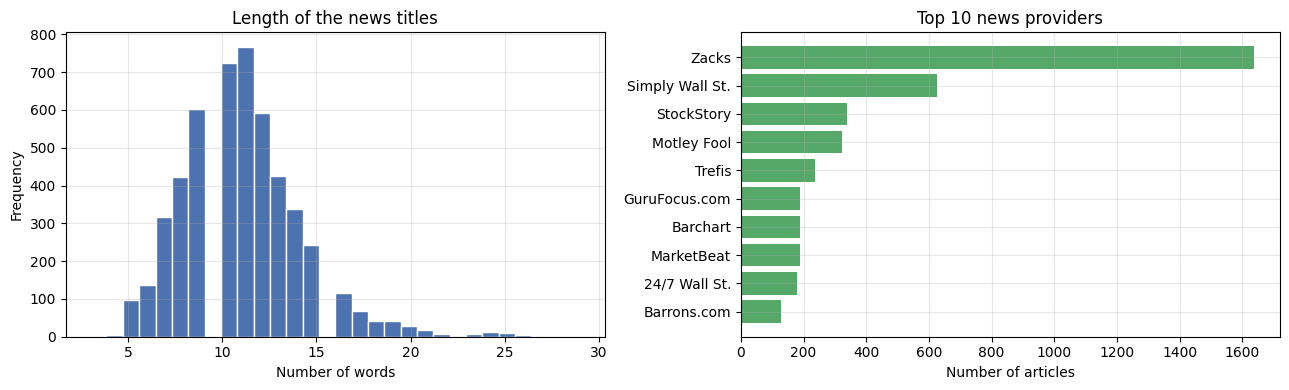

Publication dates range from 2026-03-18 15:50:58+00:00 to 2026-08-03 02:09:01+00:00


In [12]:
# Quick descriptive checks on the corpus we are about to embed
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_news['TITLE'].str.split().str.len().plot(kind='hist', bins=30, ax=axes[0],
                                            color='#4c72b0', edgecolor='white')
axes[0].set_title('Length of the news titles')
axes[0].set_xlabel('Number of words')

top_providers = df_news['PROVIDER'].value_counts().head(10)
axes[1].barh(top_providers.index[::-1].astype(str), top_providers.values[::-1], color='#55a868')
axes[1].set_title('Top 10 news providers')
axes[1].set_xlabel('Number of articles')

plt.tight_layout()
plt.show()

if df_news['PUBLICATION_DATE'].notna().any():
    print("Publication dates range from "
          f"{df_news['PUBLICATION_DATE'].min()} to {df_news['PUBLICATION_DATE'].max()}")

## Exploring text embeddings

- Use the open-source model: 'sentence-transformers/all-MiniLM-L6-v2' to create embeddings on the news title and summary
- Add a column to your news dataframe called EMBEDDED_TEXT using ONLY the TITLE of the news
- Add a column to your news dataframe called EMBEDDINGS, which contains the embedding of EMBEDDED_TEXT

`all-MiniLM-L6-v2` is a 6-layer distilled transformer that maps a sentence to a **384-dimensional**
vector, trained so that semantically similar sentences end up close to each other under cosine
similarity. It truncates inputs at 256 word-pieces — irrelevant here, since news titles are ~10–20
words.

In [13]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print(model)
print("Embedding dimension:", model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)
Embedding dimension: 384


In [14]:
# EMBEDDED_TEXT = the news TITLE only (as required)
df_news['EMBEDDED_TEXT'] = df_news['TITLE'].astype(str).str.strip()

embeddings = model.encode(df_news['EMBEDDED_TEXT'].tolist(),
                          batch_size=64,
                          show_progress_bar=True,
                          convert_to_numpy=True)

df_news['EMBEDDINGS'] = list(embeddings)

print(f"Embeddings matrix: {embeddings.shape}  (rows = articles, columns = dimensions)")
display(df_news[['TICKER', 'TITLE', 'EMBEDDED_TEXT', 'EMBEDDINGS']].head())

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings matrix: (5030, 384)  (rows = articles, columns = dimensions)


,TICKER,TITLE,EMBEDDED_TEXT,EMBEDDINGS
0,A,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,"[-0.046655934, -0.046706494, -0.029965715, 0.013323064, 0.061135408, 0.07120217, -0.07..."
1,A,Stryker (SYK) Q2 Earnings and Revenues Beat Estimates,Stryker (SYK) Q2 Earnings and Revenues Beat Estimates,"[-0.011897913, 0.018847344, -0.016226808, -0.03954951, -0.035370503, -0.038789798, 0.0..."
2,A,Avantor Stock Surged Because One Segment Stopped Shrinking,Avantor Stock Surged Because One Segment Stopped Shrinking,"[-0.012856156, -0.006029089, 0.046524283, 0.011211433, 0.06474187, -0.040015563, -0.06..."
3,A,Revvity to Report Q2 Earnings: What's in Store for the Stock?,Revvity to Report Q2 Earnings: What's in Store for the Stock?,"[-0.03479537, 0.03881338, -0.015764307, 0.06187697, -0.08389846, 0.037871663, -0.02300..."
4,A,"Philips Q2 Earnings and Revenues Increase Year over Year, Shares Down","Philips Q2 Earnings and Revenues Increase Year over Year, Shares Down","[0.040547386, 0.008779844, 0.0667828, -0.0026544433, -0.030840565, -0.0072850017, -0.0..."


In [15]:
# Sanity check: does the embedding space actually capture meaning?
# The two most similar titles in a random sample should be semantically related.
from sklearn.metrics.pairwise import cosine_similarity

sample = df_news.sample(min(200, len(df_news)), random_state=RANDOM_STATE).reset_index(drop=True)
sim = cosine_similarity(np.vstack(sample['EMBEDDINGS'].to_numpy()))
np.fill_diagonal(sim, -1)
i, j = np.unravel_index(sim.argmax(), sim.shape)

print(f"Highest cosine similarity in the sample: {sim[i, j]:.3f}")
print(f"  A ({sample.loc[i, 'TICKER']}): {sample.loc[i, 'TITLE']}")
print(f"  B ({sample.loc[j, 'TICKER']}): {sample.loc[j, 'TITLE']}")

Highest cosine similarity in the sample: 1.000
  A (AMAT): Applied Materials Rose 15% on Thursday and Is Still More Than 30% Below Its High. It Reports on Aug. 13.
  B (LRCX): Applied Materials Rose 15% on Thursday and Is Still More Than 30% Below Its High. It Reports on Aug. 13.


## Using K-means clustering on news embeddings
to simplify, keep only one news for each company (ticker), you should have 500 rows in your news dataframe

> **Why the result may be slightly under 500 rows.** One row per ticker is exactly what the cell below
> produces, but `.news` returns an empty list for some constituents on any given day (recent IPOs,
> quiet small caps, transient API failures). The number of rows is therefore
> *the number of tickers that actually had at least one usable article* — reported explicitly below,
> together with the coverage ratio, rather than silently padded to 500.

**One article per ticker is not the same as one article per *story*.** Wire services attach a single
piece to every company it mentions, so a headline such as *"Big Tech's AI shakeout just changed
everything"* can be the most recent article of six different mega-caps at once. Naively keeping the
newest article per ticker would then insert the *same* text six times into the clustering matrix — and
because K-Means centroids are means, that story would pull a centroid with six times the weight it
deserves, manufacturing a cluster out of a duplication artefact.

The selection below therefore walks each ticker in turn and takes its most recent article **whose
title has not already been used**, falling back to the newest one only if all of its articles are
duplicates. Every ticker keeps a row, and no story is counted twice.

In [16]:
# One article per ticker, avoiding the SAME syndicated story being selected for several tickers
seen_titles, picks = set(), []
ordered = df_news.sort_values(['TICKER', 'PUBLICATION_DATE'], ascending=[True, False])

for ticker, group in ordered.groupby('TICKER', sort=True):
    fresh = group[~group['TITLE'].str.lower().isin(seen_titles)]
    chosen = (fresh if not fresh.empty else group).iloc[0]      # fall back if all are duplicates
    seen_titles.add(str(chosen['TITLE']).lower())
    picks.append(chosen)

df_news_unique = pd.DataFrame(picks).reset_index(drop=True)

n_dupes_avoided = df_news_unique['TICKER'].nunique() - df_news_unique['TITLE'].str.lower().nunique()
print(f"Distinct stories among the selected articles: "
      f"{df_news_unique['TITLE'].str.lower().nunique()} / {len(df_news_unique)} "
      f"({n_dupes_avoided} tickers had only duplicated stories available)")

Distinct stories among the selected articles: 503 / 503 (0 tickers had only duplicated stories available)


In [17]:
df_news_unique['COMPANY'] = df_news_unique['TICKER'].map(meta['COMPANY'])
df_news_unique['SECTOR'] = df_news_unique['TICKER'].map(meta['SECTOR'])

X = np.vstack(df_news_unique['EMBEDDINGS'].to_numpy())

print(f"df_news_unique: {df_news_unique.shape[0]} rows (one news per ticker)")
print(f"Coverage: {df_news_unique.shape[0]}/{len(yahoo_symbols)} constituents "
      f"({df_news_unique.shape[0] / len(yahoo_symbols):.1%}) returned at least one usable article")
print(f"Embedding matrix X: {X.shape}")
display(df_news_unique[['TICKER', 'COMPANY', 'SECTOR', 'TITLE', 'PUBLICATION_DATE']].head(10))

df_news_unique: 503 rows (one news per ticker)
Coverage: 503/503 constituents (100.0%) returned at least one usable article
Embedding matrix X: (503, 384)


,TICKER,COMPANY,SECTOR,TITLE,PUBLICATION_DATE
0,A,Agilent Technologies,Health Care,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,2026-07-31 13:20:00+00:00
1,AAPL,Apple Inc.,Information Technology,"Why Retail Traders Couldn’t Take Their Eyes Off These Stocks Last Week: AAPL, MSFT, AM...",2026-08-03 02:00:38+00:00
2,ABBV,AbbVie,Health Care,Why AbbVie Stock Slumped Today,2026-08-01 00:01:21+00:00
3,ABNB,Airbnb,Consumer Discretionary,Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion,2026-07-31 23:24:00+00:00
4,ABT,Abbott Laboratories,Health Care,Abbott (ABT) Stock Looks Like A Bargain Below Fair Value,2026-08-02 17:14:20+00:00
5,ACGL,Arch Capital Group,Financials,Arch Capital Group (ACGL) Could Be 9% Below Fair Value After Earnings,2026-08-01 12:12:09+00:00
6,ACN,Accenture,Information Technology,What ACN Holders Got Paid While The Stock Fell Behind,2026-08-01 15:01:50+00:00
7,ADBE,Adobe Inc.,Information Technology,Why ADSK Stock Hands You So Much Cash Right Now,2026-08-01 16:22:53+00:00
8,ADI,Analog Devices,Information Technology,AEIS Set to Report Q2 Earnings: What's in the Cards for the Stock?,2026-07-31 14:04:00+00:00
9,ADM,Archer Daniels Midland,Consumer Staples,Archer-Daniels-Midland (ADM) Is Down 7.7% After Major Oilseed Crush Expansion And New ...,2026-08-02 04:16:12+00:00


### Identify the number of clusters using the silhouette score

- Using a for loop, do the clustering with different k values (number of clusters), test 1 to 6 clusters
- Compute the silhouette score for every k value
- Plot the silhouette score for different k values

#### Try different values of k and compute silhouette scores

> **Note on k = 1.** The silhouette score of an observation compares its average distance to its own
> cluster with its average distance to the *nearest other* cluster. With a single cluster there is no
> "other cluster", so the score is mathematically undefined (`scikit-learn` raises a `ValueError` for
> `n_labels = 1`). The loop therefore runs over **k = 2 … 6**, which is also the range required by the
> assignment brief.

In [18]:
k_values = range(2, 7)
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    rows.append({
        'K': k,
        'SILHOUETTE': silhouette_score(X, labels),          # higher is better
        'DAVIES_BOULDIN': davies_bouldin_score(X, labels),  # LOWER is better
        'CALINSKI_HARABASZ': calinski_harabasz_score(X, labels),   # higher is better
        'INERTIA': km.inertia_,
        'SMALLEST_CLUSTER': int(np.bincount(labels).min()),
        'LARGEST_CLUSTER': int(np.bincount(labels).max()),
    })
    r = rows[-1]
    print(f"k = {k} | silhouette = {r['SILHOUETTE']:.4f} | "
          f"davies-bouldin = {r['DAVIES_BOULDIN']:.4f} | "
          f"calinski-harabasz = {r['CALINSKI_HARABASZ']:.2f} | "
          f"inertia = {km.inertia_:,.0f} | sizes = {np.bincount(labels).tolist()}")

df_silhouette = pd.DataFrame(rows)
display(df_silhouette.style.format({
    'SILHOUETTE': '{:.4f}', 'DAVIES_BOULDIN': '{:.4f}',
    'CALINSKI_HARABASZ': '{:.2f}', 'INERTIA': '{:,.0f}'}))

k = 2 | silhouette = 0.0287 | davies-bouldin = 4.0305 | calinski-harabasz = 23.59 | inertia = 368 | sizes = [358, 145]
k = 3 | silhouette = 0.0328 | davies-bouldin = 4.6600 | calinski-harabasz = 19.50 | inertia = 357 | sizes = [133, 166, 204]
k = 4 | silhouette = 0.0296 | davies-bouldin = 4.7844 | calinski-harabasz = 15.53 | inertia = 352 | sizes = [99, 133, 125, 146]
k = 5 | silhouette = 0.0141 | davies-bouldin = 4.6790 | calinski-harabasz = 13.35 | inertia = 348 | sizes = [122, 129, 74, 60, 118]
k = 6 | silhouette = 0.0113 | davies-bouldin = 4.7578 | calinski-harabasz = 11.84 | inertia = 344 | sizes = [110, 104, 84, 85, 34, 86]


,K,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ,INERTIA,SMALLEST_CLUSTER,LARGEST_CLUSTER
0,2,0.0287,4.0305,23.59,368,145,358
1,3,0.0328,4.6600,19.50,357,133,204
2,4,0.0296,4.7844,15.53,352,99,146
3,5,0.0141,4.6790,13.35,348,60,129
4,6,0.0113,4.7578,11.84,344,34,110


> Silhouette (**higher** = better),
> Davies-Bouldin (**lower** = better) and Calinski-Harabasz (higher = better) measure separation in
> different ways, and on short-text embeddings they frequently point to *different* values of k. When
> they disagree, that disagreement is itself the finding: it means no k is clearly right and the
> structure is weak. The cell below states explicitly which k each metric prefers instead of assuming
> one answer.

In [19]:
verdicts = {
    'silhouette (max)': int(df_silhouette.loc[df_silhouette['SILHOUETTE'].idxmax(), 'K']),
    'davies-bouldin (min)': int(df_silhouette.loc[df_silhouette['DAVIES_BOULDIN'].idxmin(), 'K']),
    'calinski-harabasz (max)': int(df_silhouette.loc[df_silhouette['CALINSKI_HARABASZ'].idxmax(), 'K']),
}
for metric, k in verdicts.items():
    print(f"  {metric:<26} -> k = {k}")

if len(set(verdicts.values())) == 1:
    print(f"\nAll three metrics agree on k = {list(verdicts.values())[0]}.")
else:
    print("\nThe metrics DISAGREE. No value of k is clearly optimal, which is evidence that the "
          "corpus has weak cluster structure rather than evidence for any particular k.")

  silhouette (max)           -> k = 3
  davies-bouldin (min)       -> k = 2
  calinski-harabasz (max)    -> k = 2

The metrics DISAGREE. No value of k is clearly optimal, which is evidence that the corpus has weak cluster structure rather than evidence for any particular k.


#### Plot silhouette scores

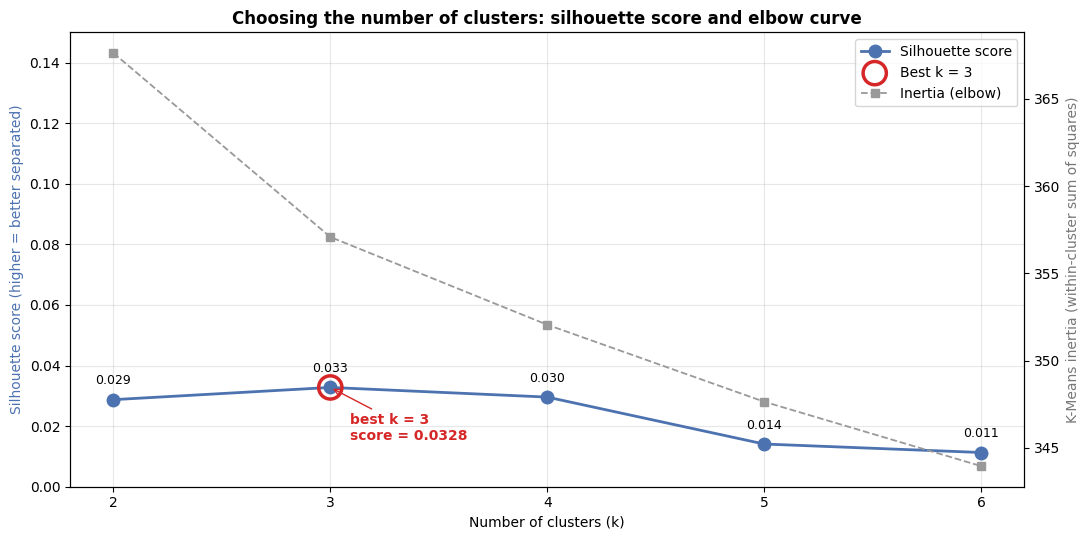

In [20]:
best_k = int(df_silhouette.loc[df_silhouette['SILHOUETTE'].idxmax(), 'K'])
best_score = df_silhouette['SILHOUETTE'].max()

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.plot(df_silhouette['K'], df_silhouette['SILHOUETTE'], 'o-', color='#4c72b0',
         lw=2, ms=9, label='Silhouette score')
ax1.scatter([best_k], [best_score], s=280, facecolor='none', edgecolor='#d62728',
            lw=2.5, zorder=5, label=f'Best k = {best_k}')
# Put the callout on the inner side of the curve so it never runs off the axes
dx = -110 if best_k >= max(k_values) else 14
ax1.annotate(f'best k = {best_k}\nscore = {best_score:.4f}',
             xy=(best_k, best_score), xytext=(dx, -38), textcoords='offset points',
             fontsize=10, color='#d62728', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#d62728'))

for _, r in df_silhouette.iterrows():
    ax1.annotate(f"{r['SILHOUETTE']:.3f}", (r['K'], r['SILHOUETTE']),
                 textcoords='offset points', xytext=(0, 11), ha='center', fontsize=9)

ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Silhouette score (higher = better separated)', color='#4c72b0')
ax1.set_xticks(list(k_values))
ax1.set_ylim(0, max(0.15, best_score * 1.5))

# The elbow curve on a secondary axis, as a cross-check on the silhouette
ax2 = ax1.twinx()
ax2.plot(df_silhouette['K'], df_silhouette['INERTIA'], 's--', color='#999999',
         lw=1.3, ms=6, label='Inertia (elbow method)')
ax2.set_ylabel('K-Means inertia (within-cluster sum of squares)', color='#777777')
ax2.grid(False)

lines = ax1.get_lines()[:1] + [ax1.collections[0]] + ax2.get_lines()
ax1.legend(lines, ['Silhouette score', f'Best k = {best_k}', 'Inertia (elbow)'], loc='best')
ax1.set_title('Choosing the number of clusters: silhouette score and elbow curve',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Identify the Best k

In [21]:
display(Markdown(
    f"**Best k according to the silhouette score: `k = {best_k}` "
    f"(score = {best_score:.4f})**\n\n"
    f"Ranking of the tested values: "
    + ", ".join(f"k={int(r.K)} ({r.SILHOUETTE:.4f})"
                for r in df_silhouette.sort_values('SILHOUETTE', ascending=False).itertuples())
))

print("\nInterpretation guide for silhouette values:")
print("   > 0.50  strong, well-separated structure")
print("  0.25-0.50 reasonable structure")
print("   < 0.25  weak structure — clusters overlap heavily (usual for short-text embeddings)")

**Best k according to the silhouette score: `k = 3` (score = 0.0328)**

Ranking of the tested values: k=3 (0.0328), k=4 (0.0296), k=2 (0.0287), k=5 (0.0141), k=6 (0.0113)


Interpretation guide for silhouette values:
   > 0.50  strong, well-separated structure
  0.25-0.50 reasonable structure
   < 0.25  weak structure — clusters overlap heavily (usual for short-text embeddings)


#### Cluster the embeddings using 3 clusters (k=3)

In [22]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
labels_k3 = kmeans.fit_predict(X)

# Add the cluster label to the news dataframe (required deliverable)
df_news_unique['CLUSTER'] = labels_k3

# Keep the best-k partition alongside, to compare the two solutions
kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_news_unique['CLUSTER_BEST_K'] = kmeans_best.fit_predict(X)

print(f"K-Means with k = {K_FINAL} | inertia = {kmeans.inertia_:,.0f} | "
      f"silhouette = {silhouette_score(X, labels_k3):.4f}")
print("\nCluster sizes:")
print(df_news_unique['CLUSTER'].value_counts().sort_index().to_string())
display(df_news_unique[['TICKER', 'COMPANY', 'TITLE', 'CLUSTER', 'CLUSTER_BEST_K']].head(10))

K-Means with k = 3 | inertia = 357 | silhouette = 0.0328

Cluster sizes:
CLUSTER
0    133
1    166
2    204


,TICKER,COMPANY,TITLE,CLUSTER,CLUSTER_BEST_K
0,A,Agilent Technologies,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,1,1
1,AAPL,Apple Inc.,"Why Retail Traders Couldn’t Take Their Eyes Off These Stocks Last Week: AAPL, MSFT, AM...",2,2
2,ABBV,AbbVie,Why AbbVie Stock Slumped Today,2,2
3,ABNB,Airbnb,Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion,0,0
4,ABT,Abbott Laboratories,Abbott (ABT) Stock Looks Like A Bargain Below Fair Value,2,2
5,ACGL,Arch Capital Group,Arch Capital Group (ACGL) Could Be 9% Below Fair Value After Earnings,2,2
6,ACN,Accenture,What ACN Holders Got Paid While The Stock Fell Behind,2,2
7,ADBE,Adobe Inc.,Why ADSK Stock Hands You So Much Cash Right Now,2,2
8,ADI,Analog Devices,AEIS Set to Report Q2 Earnings: What's in the Cards for the Stock?,0,0
9,ADM,Archer Daniels Midland,Archer-Daniels-Midland (ADM) Is Down 7.7% After Major Oilseed Crush Expansion And New ...,1,1


In [23]:
# Per-observation silhouette: which cluster is compact, and how many points are misassigned?
sil_values = silhouette_samples(X, labels_k3)
df_news_unique['SILHOUETTE'] = sil_values

quality = (df_news_unique.groupby('CLUSTER')['SILHOUETTE']
           .agg(SIZE='size', MEAN_SILHOUETTE='mean', MIN='min', MAX='max'))
quality['NEGATIVE_SILHOUETTE'] = (df_news_unique.assign(neg=sil_values < 0)
                                  .groupby('CLUSTER')['neg'].sum())
display(quality.style.format({'MEAN_SILHOUETTE': '{:.3f}', 'MIN': '{:.3f}', 'MAX': '{:.3f}'}))
print(f"\nArticles with a negative silhouette (closer to another cluster): "
      f"{(sil_values < 0).sum()} / {len(sil_values)} ({(sil_values < 0).mean():.1%})")

,SIZE,MEAN_SILHOUETTE,MIN,MAX,NEGATIVE_SILHOUETTE
CLUSTER,,,,,
0,133,0.113,0.042,0.196,0
1,166,-0.031,-0.090,0.019,144
2,204,0.032,-0.038,0.082,26



Articles with a negative silhouette (closer to another cluster): 170 / 503 (33.8%)


#### Optional: Yellowbrick diagnostics (Intercluster Distance Map + Silhouette Visualizer)

Two visual cross-checks on the partition. The **Intercluster Distance Map** projects the centroids and
scales each circle by cluster membership: heavily overlapping circles mean the clusters are not
separated in the embedding space. The **Silhouette Visualizer** draws the silhouette of every single
article, so the share of the corpus falling below zero — the articles that are closer to another
cluster than to their own — is visible at a glance instead of hidden in an average.

The cell degrades gracefully: if `yellowbrick` cannot be installed (it pins older scikit-learn
versions and occasionally conflicts), the notebook keeps running.

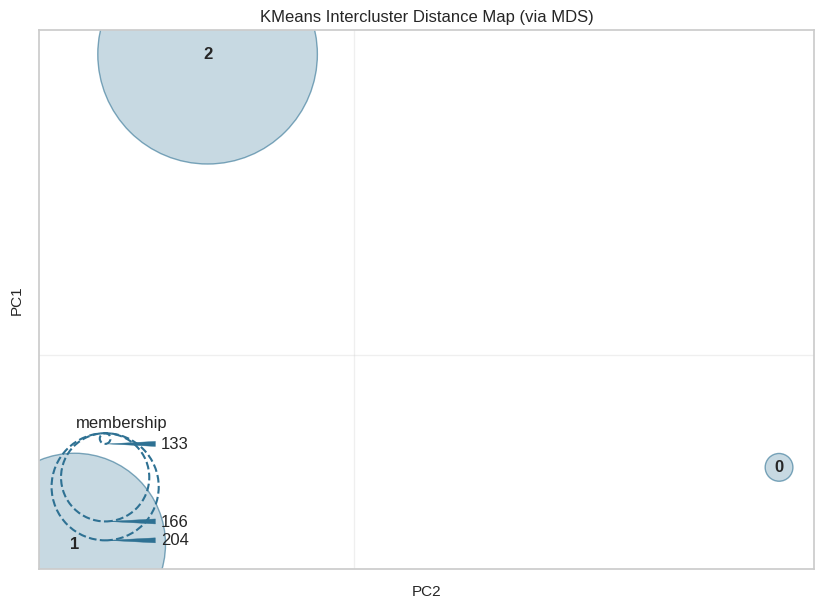

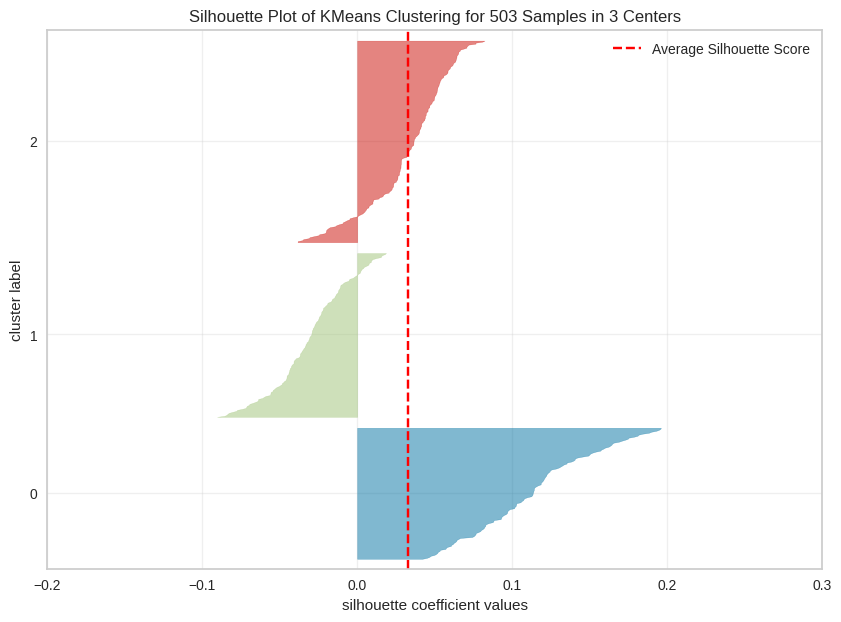

In [24]:
try:
    from yellowbrick.cluster import InterclusterDistance, SilhouetteVisualizer

    km_vis = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)

    fig, ax = plt.subplots(figsize=(10, 7))
    viz = InterclusterDistance(km_vis, ax=ax, random_state=RANDOM_STATE)
    viz.fit(X)
    viz.show()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 7))
    viz = SilhouetteVisualizer(KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10),
                               colors='yellowbrick', ax=ax)
    viz.fit(X)
    viz.show()
    plt.show()
except Exception as exc:
    print(f"Yellowbrick diagnostics skipped ({type(exc).__name__}: {exc}).")
    print("The silhouette table, the silhouette plot and the per-article silhouette column above "
          "already cover the same diagnostics.")

### Visualize the 2 first PCA Components of your embeddings

In [25]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
df_news_unique['PCA_1'], df_news_unique['PCA_2'] = coords[:, 0], coords[:, 1]

explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]:.2%}")
print(f"Variance explained by PC2: {explained[1]:.2%}")
print(f"Total variance captured by the 2D plot: {explained.sum():.2%}")

Variance explained by PC1: 5.77%
Variance explained by PC2: 3.95%
Total variance captured by the 2D plot: 9.73%


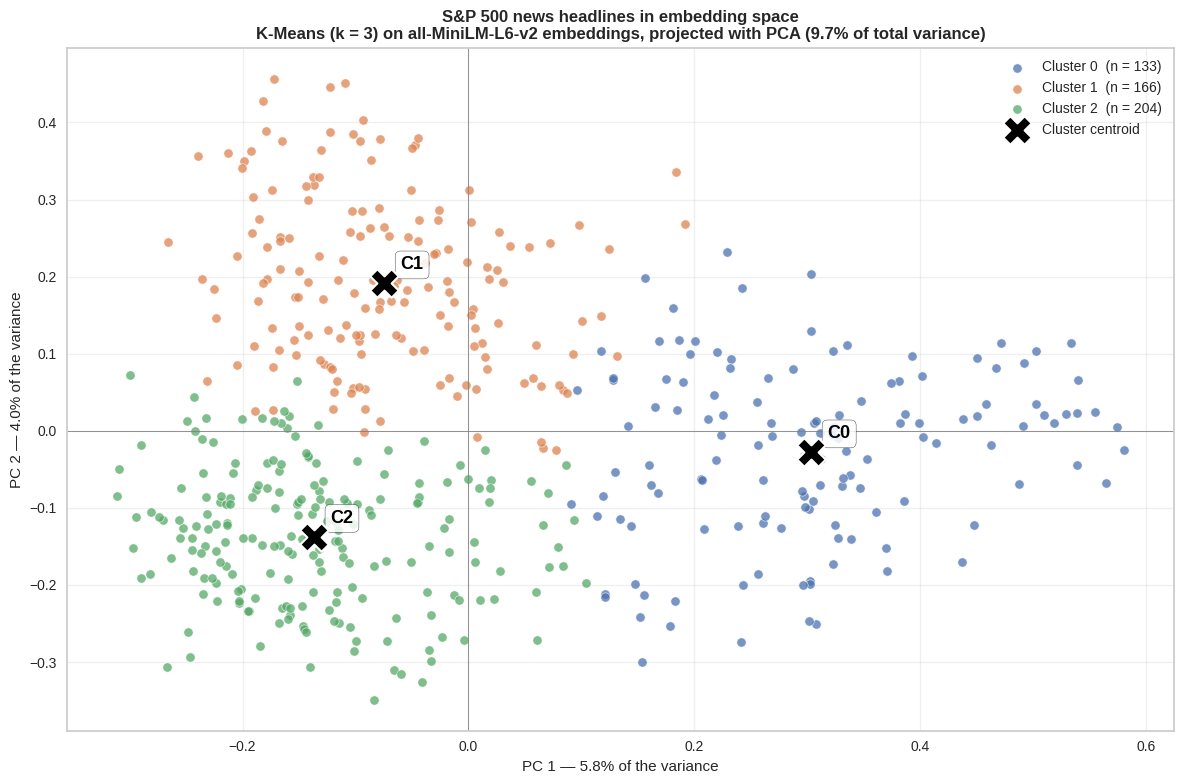

In [26]:
PALETTE = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860']

fig, ax = plt.subplots(figsize=(12, 8))

for cluster in sorted(df_news_unique['CLUSTER'].unique()):
    sub = df_news_unique[df_news_unique['CLUSTER'] == cluster]
    ax.scatter(sub['PCA_1'], sub['PCA_2'], s=45, alpha=0.75,
               color=PALETTE[cluster % len(PALETTE)], edgecolor='white', linewidth=0.5,
               label=f'Cluster {cluster}  (n = {len(sub)})')

# Centroids projected into the same 2D space
centroids_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='X', s=420,
           c='black', edgecolor='white', linewidth=1.5, zorder=6, label='Cluster centroid')
for cluster, (x, y) in enumerate(centroids_2d):
    ax.annotate(f'C{cluster}', (x, y), fontsize=13, fontweight='bold', color='black',
                xytext=(12, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.85))

ax.set_xlabel(f'PC 1 — {explained[0]:.1%} of the variance')
ax.set_ylabel(f'PC 2 — {explained[1]:.1%} of the variance')
ax.set_title(f'S&P 500 news headlines in embedding space\n'
             f'K-Means (k = {K_FINAL}) on all-MiniLM-L6-v2 embeddings, projected with PCA '
             f'({explained.sum():.1%} of total variance)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', framealpha=0.92)
ax.axhline(0, color='grey', lw=0.6)
ax.axvline(0, color='grey', lw=0.6)
plt.tight_layout()
plt.show()

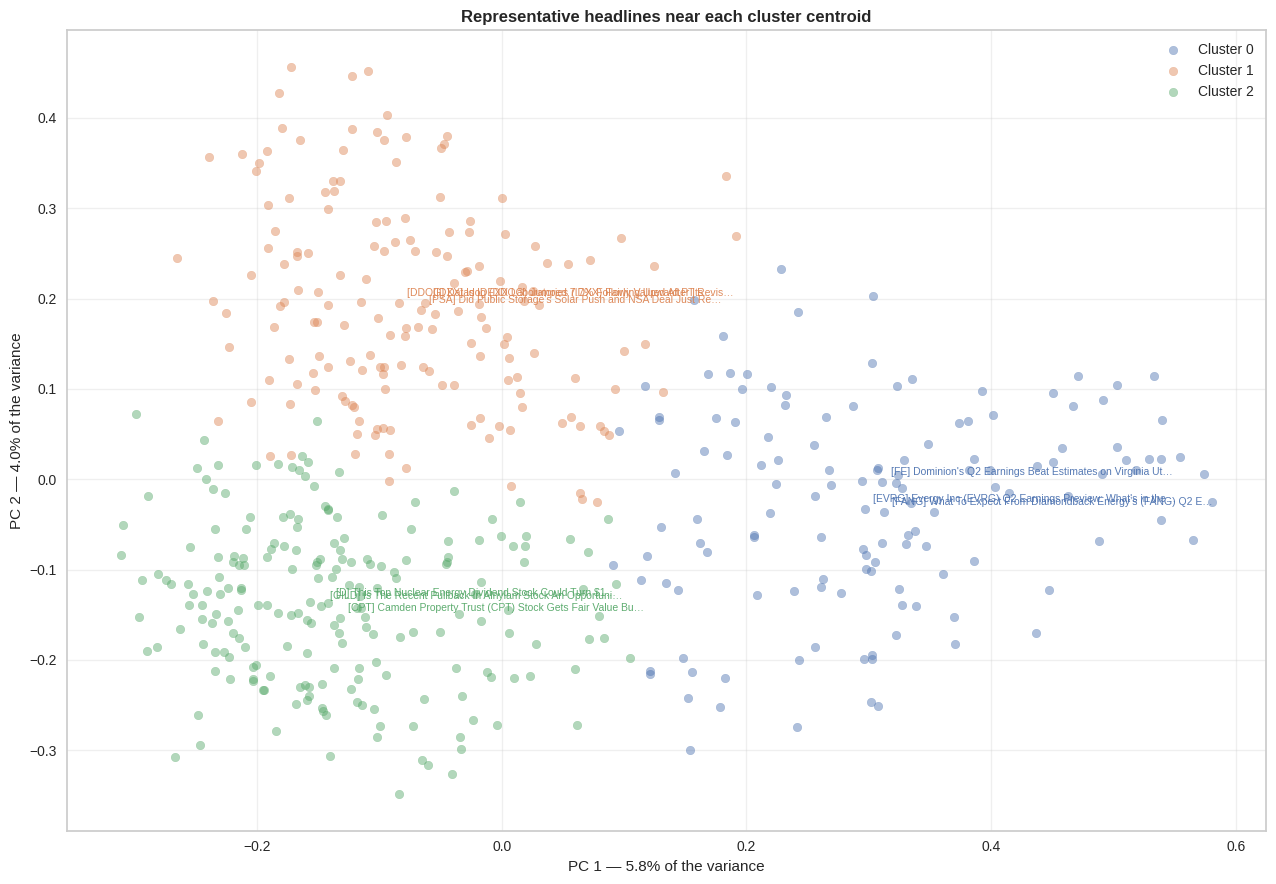

In [27]:
# Same projection, annotated with a few real headlines so the axes become interpretable
fig, ax = plt.subplots(figsize=(13, 9))

for cluster in sorted(df_news_unique['CLUSTER'].unique()):
    sub = df_news_unique[df_news_unique['CLUSTER'] == cluster]
    ax.scatter(sub['PCA_1'], sub['PCA_2'], s=38, alpha=0.45,
               color=PALETTE[cluster % len(PALETTE)], label=f'Cluster {cluster}')

    # Annotate the 3 headlines closest to each centroid (the most "typical" ones)
    centre = np.array([sub['PCA_1'].mean(), sub['PCA_2'].mean()])
    dist = np.linalg.norm(sub[['PCA_1', 'PCA_2']].to_numpy() - centre, axis=1)
    for idx in sub.index[np.argsort(dist)[:3]]:
        row = df_news_unique.loc[idx]
        text = (row['TITLE'][:52] + '…') if len(row['TITLE']) > 52 else row['TITLE']
        ax.annotate(f"[{row['TICKER']}] {text}", (row['PCA_1'], row['PCA_2']),
                    fontsize=7.5, alpha=0.95,
                    color=PALETTE[cluster % len(PALETTE)],
                    xytext=(6, 5), textcoords='offset points')

ax.set_xlabel(f'PC 1 — {explained[0]:.1%} of the variance')
ax.set_ylabel(f'PC 2 — {explained[1]:.1%} of the variance')
ax.set_title('Representative headlines near each cluster centroid', fontsize=12, fontweight='bold')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

#### Analyze the content of each cluster
- Add the kmeans cluster label to your news dataframe
- Print the content of each cluster and analyze it

In [28]:
def top_terms_per_cluster(df, text_col='TITLE', label_col='CLUSTER', n_terms=12):
    """Terms that are most characteristic of each cluster, via TF-IDF centroids."""
    vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 2),
                          min_df=2, max_features=5000)
    tfidf = vec.fit_transform(df[text_col].astype(str))
    vocab = np.array(vec.get_feature_names_out())

    out = {}
    for cluster in sorted(df[label_col].unique()):
        mask = (df[label_col] == cluster).to_numpy()
        centroid = np.asarray(tfidf[mask].mean(axis=0)).ravel()
        out[cluster] = vocab[centroid.argsort()[::-1][:n_terms]].tolist()
    return out


cluster_terms = top_terms_per_cluster(df_news_unique)
for cluster, terms in cluster_terms.items():
    print(f"\nCluster {cluster} ({(df_news_unique['CLUSTER'] == cluster).sum()} articles)")
    print("  characteristic terms:", ", ".join(terms))


Cluster 0 (133 articles)
  characteristic terms: q2, earnings, q2 earnings, earnings highlights, highlights, estimates, beat, revenues, q2 2026, 2026, 2026 earnings, report

Cluster 1 (166 articles)
  characteristic terms: ai, billion, growth, deep, q2 deep, deep dive, dive, just, faces, market, new, ceo

Cluster 2 (204 articles)
  characteristic terms: stock, stocks, earnings, buy, dividend, value, looks, fair, stock looks, undervalued, week, vs


In [29]:
# Print a readable sample of each cluster: the most typical headlines (highest silhouette)
for cluster in sorted(df_news_unique['CLUSTER'].unique()):
    sub = (df_news_unique[df_news_unique['CLUSTER'] == cluster]
           .sort_values('SILHOUETTE', ascending=False))
    display(Markdown(
        f"### Cluster {cluster} — {len(sub)} articles "
        f"(mean silhouette {sub['SILHOUETTE'].mean():.3f})\n"
        f"**Characteristic terms:** {', '.join(cluster_terms[cluster])}"
    ))
    print("MOST REPRESENTATIVE HEADLINES (closest to the cluster core)")
    for _, row in sub.head(10).iterrows():
        print(f"  [{row['TICKER']:<6}] {row['TITLE']}")
    print("\nLEAST REPRESENTATIVE HEADLINES (borderline cases)")
    for _, row in sub.tail(3).iterrows():
        print(f"  [{row['TICKER']:<6}] {row['TITLE']}  (silhouette {row['SILHOUETTE']:.3f})")
    print()

### Cluster 0 — 133 articles (mean silhouette 0.113)
**Characteristic terms:** q2, earnings, q2 earnings, earnings highlights, highlights, estimates, beat, revenues, q2 2026, 2026, 2026 earnings, report

MOST REPRESENTATIVE HEADLINES (closest to the cluster core)
  [TRV   ] Definity Financial Q2 Earnings Call Highlights
  [AIZ   ] Assurant Set to Report Q2 Earnings: What's in the Cards?
  [SO    ] Southern Q2 Earnings Call Highlights
  [FCX   ] Olin Q2 Earnings Call Highlights
  [MAA   ] Mid-America Apartment Communities Q2 Earnings Call Highlights
  [VTR   ] Ventas Q2 Earnings Call Highlights
  [TYL   ] Tyler Technologies Q2 Earnings Call Highlights
  [UNH   ] Guardant Health Q2 Earnings Call Highlights
  [BLDR  ] Builders FirstSource Q2 Earnings Call Highlights
  [WEC   ] WEC Energy Group Q2 Earnings Call Highlights

LEAST REPRESENTATIVE HEADLINES (borderline cases)
  [WELL  ] Welltower (WELL) Earnings Beat Keeps Fair Value In Focus  (silhouette 0.047)
  [CDW   ] CDW (CDW) Earnings Expected to Grow: What to Know Ahead of Next Week's Release  (silhouette 0.045)
  [DD    ] Analysts Estimate Tronox (TROX) to Report a Decline in Earnings: What to Look Out for  (silhouette 0.042)



### Cluster 1 — 166 articles (mean silhouette -0.031)
**Characteristic terms:** ai, billion, growth, deep, q2 deep, deep dive, dive, just, faces, market, new, ceo

MOST REPRESENTATIVE HEADLINES (closest to the cluster core)
  [FTNT  ] Fortinet: Securing the AI Revolution
  [AKAM  ] Akamai (AKAM) Joins Tenzai To Bring Instant Vulnerability Mitigation To The Edge
  [CEG   ] El Niño Hits the Panama Canal
  [UBER  ] Uber (UBER) Faces Wrongful Death Lawsuit Over Fatal Uber Eats Delivery
  [NEE   ] Does US$100 Billion Paducah AI Power Campus Plan Change The Bull Case For NextEra Energy (NEE)?
  [DASH  ] DoorDash (DASH) Just Won FAA Approval And Launched Its Own Drone Delivery Service
  [COST  ] Costco's changes fix members' biggest problems
  [CSGP  ] South Florida Multifamily Faces Fragile Recovery Amid Oversupply
  [NFLX  ] A Wild Netflix Lawsuit Shows Why Drugs and Alcohol Don’t Mix With Work
  [MDLZ  ] Mondelez (MDLZ) Tackles Cocoa Costs While Recalling Cadbury Oreo Candy Bar

LEAST REPRESENTATIVE HEADLINES (borderline cases)
  [HD    ] Masco Earnings Rise as Pricing and Tariff Refunds Lift 2026 Margins  (silhouette -0.084)
  [HAL   ] Is Halliburto

### Cluster 2 — 204 articles (mean silhouette 0.032)
**Characteristic terms:** stock, stocks, earnings, buy, dividend, value, looks, fair, stock looks, undervalued, week, vs

MOST REPRESENTATIVE HEADLINES (closest to the cluster core)
  [KR    ] 3 Magnificent Stocks to Buy That Are Near 52-Week Lows
  [GD    ] This Is the Most Attractive Defense Stock Right Now
  [WMT   ] Jim Cramer says Wall Street is 'fleeing' AI stocks after a 7% drop — and buying Salesforce, Walmart instead
  [SHW   ] Stocks making big moves this week: Huron, Sherwin-Williams, PROG, CONMED, and Freshworks
  [INTC  ] 1 Beaten-Down Semiconductor Stock That Could Make a Comeback
  [OKE   ] 3 High-Yield Energy Stocks to Buy With $1,000 Right Now and Hold Through 2030
  [CVX   ] 4 Dividend Energy Stocks to Buy This Month, Starting With ExxonMobil
  [ORCL  ] Oracle and Nvidia Shares Have Plunged Over the Past 3 Months. Is It Time to Cut These Tech Stocks Loose?
  [PAYX  ] 1 Software Stock to Own for Decades and 2 We Avoid
  [PSKY  ] With Paramount's Acquisition of Warner Bros. on Hold and Netflix Down 38%, Is Netflix Stock Finally a Buy?

LEAST REPRESENTATIVE HEADLINES (borderline cases)
  [M

In [30]:
# Are the clusters just a re-labelling of GICS sectors? A cross-tab answers directly.
sector_mix = pd.crosstab(df_news_unique['SECTOR'], df_news_unique['CLUSTER'], normalize='columns')
display(sector_mix.style.format('{:.1%}').background_gradient(cmap='Blues', axis=None))

print("If every column has a similar sector profile, the clusters capture the TYPE of news "
      "(earnings, M&A, analyst notes...) rather than the industry of the company.")

CLUSTER,0,1,2
SECTOR,,,
Communication Services,3.8%,6.6%,3.4%
Consumer Discretionary,8.3%,10.8%,8.8%
Consumer Staples,4.5%,9.6%,5.9%
Energy,3.8%,3.0%,5.4%
Financials,16.5%,13.9%,15.2%
Health Care,10.5%,14.5%,10.3%
Industrials,13.5%,17.5%,16.7%
Information Technology,9.0%,13.3%,19.6%
Materials,6.0%,2.4%,6.9%


If every column has a similar sector profile, the clusters capture the TYPE of news (earnings, M&A, analyst notes...) rather than the industry of the company.


In [31]:
# Cluster sizes and a compact summary table of the final result
summary = (df_news_unique.groupby('CLUSTER')
           .agg(ARTICLES=('TITLE', 'size'),
                MEAN_SILHOUETTE=('SILHOUETTE', 'mean'),
                TOP_SECTOR=('SECTOR', lambda s: s.value_counts().idxmax()),
                EXAMPLE_TITLE=('TITLE', 'first')))
summary['TOP_TERMS'] = [', '.join(cluster_terms[c][:6]) for c in summary.index]
display(summary[['ARTICLES', 'MEAN_SILHOUETTE', 'TOP_SECTOR', 'TOP_TERMS', 'EXAMPLE_TITLE']]
        .style.format({'MEAN_SILHOUETTE': '{:.3f}'}))

,ARTICLES,MEAN_SILHOUETTE,TOP_SECTOR,TOP_TERMS,EXAMPLE_TITLE
CLUSTER,,,,,
0,133,0.113,Financials,"q2, earnings, q2 earnings, earnings highlights, highlights, estimates",Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion
1,166,-0.031,Industrials,"ai, billion, growth, deep, q2 deep, deep dive",How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends
2,204,0.032,Information Technology,"stock, stocks, earnings, buy, dividend, value","Why Retail Traders Couldn’t Take Their Eyes Off These Stocks Last Week: AAPL, MSFT, AMZN, META, TSLA"


In [32]:
# The final deliverable: the news DataFrame with embeddings and cluster labels
display(df_news_unique[['TICKER', 'COMPANY', 'SECTOR', 'TITLE', 'PUBLICATION_DATE',
                        'PROVIDER', 'CLUSTER', 'CLUSTER_BEST_K', 'SILHOUETTE']].head(20))

df_news_unique.to_csv('sp500_news_clustered.csv', index=False)
print(f"\nSaved {len(df_news_unique)} clustered articles to sp500_news_clustered.csv")

,TICKER,COMPANY,SECTOR,TITLE,PUBLICATION_DATE,PROVIDER,CLUSTER,CLUSTER_BEST_K,SILHOUETTE
0,A,Agilent Technologies,Health Care,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,2026-07-31 13:20:00+00:00,Zacks,1,1,-0.014196
1,AAPL,Apple Inc.,Information Technology,"Why Retail Traders Couldn’t Take Their Eyes Off These Stocks Last Week: AAPL, MSFT, AM...",2026-08-03 02:00:38+00:00,Stocktwits,2,2,0.064705
2,ABBV,AbbVie,Health Care,Why AbbVie Stock Slumped Today,2026-08-01 00:01:21+00:00,Motley Fool,2,2,0.051222
3,ABNB,Airbnb,Consumer Discretionary,Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion,2026-07-31 23:24:00+00:00,Zacks,0,0,0.125373
4,ABT,Abbott Laboratories,Health Care,Abbott (ABT) Stock Looks Like A Bargain Below Fair Value,2026-08-02 17:14:20+00:00,Simply Wall St.,2,2,0.049772
5,ACGL,Arch Capital Group,Financials,Arch Capital Group (ACGL) Could Be 9% Below Fair Value After Earnings,2026-08-01 12:12:09+00:00,Simply Wall St.,2,2,0.004841
6,ACN,Accenture,Information Technology,What ACN Holders Got Paid While The Stock Fell Behind,2026-08-01 15:01:50+00:00,Trefis,2,2,0.023219
7,ADBE,Adobe Inc.,Information Technology,Why ADSK Stock Hands You So Much Cash Right Now,2026-08-01 16:22:53+00:00,Trefis,2,2,0.044243
8,ADI,Analog Devices,Information Technology,AEIS Set to Report Q2 Earnings: What's in the Cards for the Stock?,2026-07-31 14:04:00+00:00,Zacks,0,0,0.139557
9,ADM,Archer Daniels Midland,Consumer Staples,Archer-Daniels-Midland (ADM) Is Down 7.7% After Major Oilseed Crush Expansion And New ...,2026-08-02 04:16:12+00:00,Simply Wall St.,1,1,-0.044133



Saved 503 clustered articles to sp500_news_clustered.csv


---
## Aligning the method with what the data actually contains

The diagnostics above are unambiguous: a silhouette near 0.03, a third of the corpus with a negative
silhouette, three internal indices that disagree about *k*, and an inertia curve with no elbow. Rather
than assert three themes the geometry does not support, this section **tests two concrete fixes** and
reports honestly whether they help. The required deliverable (`CLUSTER`, K-Means with k = 3 on the raw
embeddings) is left untouched — this is a controlled comparison next to it, not a replacement.

**Fix 1 — remove the entity from the text.** Headlines name the company, and the encoder keys on that
name. "*Southern* Q2 Earnings Call Highlights" and "*Ventas* Q2 Earnings Call Highlights" should be
near-identical for our purposes, and stripping the company name and ticker forces the model to
represent the *event* rather than the subject.

**Fix 2 — reduce the dimensionality before clustering.** In 384 dimensions distances concentrate and
every point looks equidistant from every other, which is the most likely cause of the flat silhouette.
Projecting onto the first 50 principal components keeps most of the usable signal while giving K-Means
a space where Euclidean distance is more meaningful.

> **A caveat that must accompany the table below:** silhouette values are *not* strictly comparable
> across spaces of different dimensionality — a score computed on 50 components is expected to be
> higher than one on 384 for purely geometric reasons. The comparison is still informative, but the
> honest reading is a *relative* one, and the entity-stripping comparison (same dimensionality) is the
> cleaner of the two experiments.

In [33]:
import re


def strip_entity(title, ticker, company):
    """Remove the company name and ticker so the encoder cannot cluster on the entity itself."""
    text = str(title)
    if isinstance(company, str) and company:
        text = re.sub(re.escape(company), ' ', text, flags=re.I)
        first_word = company.split()[0]
        if len(first_word) > 3:
            text = re.sub(rf'\b{re.escape(first_word)}\b', ' ', text, flags=re.I)
    text = re.sub(rf'\b{re.escape(str(ticker))}\b', ' ', text, flags=re.I)
    text = re.sub(r'\(\s*\)', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


df_news_unique['TITLE_NO_ENTITY'] = [
    strip_entity(t, k, c)
    for t, k, c in zip(df_news_unique['TITLE'], df_news_unique['TICKER'], df_news_unique['COMPANY'])
]

print("Before / after entity stripping:")
for _, row in df_news_unique.head(4).iterrows():
    print(f"  [{row['TICKER']}] {row['TITLE'][:70]}")
    print(f"        -> {row['TITLE_NO_ENTITY'][:70]}")

Before / after entity stripping:
  [A] How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends
        -> How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends
  [AAPL] Why Retail Traders Couldn’t Take Their Eyes Off These Stocks Last Week
        -> Why Retail Traders Couldn’t Take Their Eyes Off These Stocks Last Week
  [ABBV] Why AbbVie Stock Slumped Today
        -> Why Stock Slumped Today
  [ABNB] Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Ex
        -> Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Ex


In [34]:
X_no_entity = model.encode(df_news_unique['TITLE_NO_ENTITY'].tolist(),
                           batch_size=64, show_progress_bar=True, convert_to_numpy=True)

pca50 = PCA(n_components=min(50, X.shape[0] - 1, X.shape[1]), random_state=RANDOM_STATE)
X_pca = pca50.fit_transform(X)
X_pca_no_entity = None   # assigned below, after the diagnostics

pca50_ne = PCA(n_components=pca50.n_components_, random_state=RANDOM_STATE).fit(X_no_entity)

print(f"Distinct texts: {df_news_unique['TITLE'].nunique()} raw titles -> "
      f"{df_news_unique['TITLE_NO_ENTITY'].nunique()} after removing the entity")
print(f"PCA-{pca50.n_components_} retains {pca50.explained_variance_ratio_.sum():.1%} of the variance "
      f"(baseline) and {pca50_ne.explained_variance_ratio_.sum():.1%} (entity removed); "
      f"the 2 components used in the scatter plot retain {explained.sum():.1%}")
print("   If a variant retains ~100%, its embeddings already live in fewer than "
      f"{pca50.n_components_} dimensions and PCA is then a distance-preserving rotation, "
      "so its metrics will match the full-dimensional row exactly.")

X_pca_no_entity = pca50_ne.transform(X_no_entity)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Distinct texts: 503 raw titles -> 482 after removing the entity
PCA-50 retains 60.4% of the variance (baseline) and 64.7% (entity removed); the 2 components used in the scatter plot retain 9.7%
   If a variant retains ~100%, its embeddings already live in fewer than 50 dimensions and PCA is then a distance-preserving rotation, so its metrics will match the full-dimensional row exactly.


In [35]:
def cluster_quality(matrix, name, k=K_FINAL):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(matrix)
    sil = silhouette_samples(matrix, labels)
    return {
        'VARIANT': name,
        'DIMS': matrix.shape[1],
        'SILHOUETTE': sil.mean(),
        'DAVIES_BOULDIN': davies_bouldin_score(matrix, labels),
        'CALINSKI_HARABASZ': calinski_harabasz_score(matrix, labels),
        'PCT_NEGATIVE': (sil < 0).mean(),
        'SMALLEST_CLUSTER': int(np.bincount(labels).min()),
    }, labels


results, label_sets = [], {}
for matrix, name in ((X, 'baseline (title, 384-d)'),
                     (X_no_entity, 'entity removed (384-d)'),
                     (X_pca, 'baseline + PCA-50'),
                     (X_pca_no_entity, 'entity removed + PCA-50')):
    row, labels = cluster_quality(matrix, name)
    results.append(row)
    label_sets[name] = labels

df_variants = pd.DataFrame(results)
display(df_variants.style.format({
    'SILHOUETTE': '{:.4f}', 'DAVIES_BOULDIN': '{:.4f}',
    'CALINSKI_HARABASZ': '{:.2f}', 'PCT_NEGATIVE': '{:.1%}'}))

best = df_variants.loc[df_variants['SILHOUETTE'].idxmax()]
base = df_variants.iloc[0]
print(f"\nBest variant: {best['VARIANT']} "
      f"(silhouette {best['SILHOUETTE']:.4f} vs {base['SILHOUETTE']:.4f} baseline, "
      f"{best['PCT_NEGATIVE']:.1%} vs {base['PCT_NEGATIVE']:.1%} misassigned)")

# Same-dimensionality comparison: the clean experiment
delta = df_variants.iloc[1]['SILHOUETTE'] - base['SILHOUETTE']
print(f"Entity stripping alone (same 384-d space): silhouette {delta:+.4f}, "
      f"misassigned {df_variants.iloc[1]['PCT_NEGATIVE'] - base['PCT_NEGATIVE']:+.1%}")

,VARIANT,DIMS,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ,PCT_NEGATIVE,SMALLEST_CLUSTER
0,"baseline (title, 384-d)",384,0.0328,4.6600,19.50,33.8%,133
1,entity removed (384-d),384,0.0504,4.0437,26.82,32.8%,137
2,baseline + PCA-50,50,0.0703,3.5338,33.79,20.9%,134
3,entity removed + PCA-50,50,0.0932,3.1410,43.75,15.7%,136



Best variant: entity removed + PCA-50 (silhouette 0.0932 vs 0.0328 baseline, 15.7% vs 33.8% misassigned)
Entity stripping alone (same 384-d space): silhouette +0.0176, misassigned -1.0%


In [36]:
# Does the improved variant tell the same story? Compare the partitions themselves.
from sklearn.metrics import adjusted_rand_score

df_news_unique['CLUSTER_ALIGNED'] = label_sets[best['VARIANT']]
ari = adjusted_rand_score(df_news_unique['CLUSTER'], df_news_unique['CLUSTER_ALIGNED'])

print(f"Adjusted Rand Index between the required partition and the best variant: {ari:.3f}")
print("   ~1.0 = same grouping under different labels | ~0.0 = unrelated groupings\n")
display(pd.crosstab(df_news_unique['CLUSTER'], df_news_unique['CLUSTER_ALIGNED'],
                    rownames=['required (raw, k=3)'], colnames=['aligned variant']))

aligned_terms = top_terms_per_cluster(df_news_unique, label_col='CLUSTER_ALIGNED')
for cluster, terms in aligned_terms.items():
    n = (df_news_unique['CLUSTER_ALIGNED'] == cluster).sum()
    print(f"\nAligned cluster {cluster} ({n} articles): {', '.join(terms[:10])}")

Adjusted Rand Index between the required partition and the best variant: 0.826
   ~1.0 = same grouping under different labels | ~0.0 = unrelated groupings



aligned variant,0,1,2
"required (raw, k=3)",,,
0,128,2,3
1,4,13,149
2,4,196,4



Aligned cluster 0 (136 articles): q2, earnings, q2 earnings, earnings highlights, highlights, estimates, beat, q2 2026, 2026, 2026 earnings

Aligned cluster 1 (211 articles): stock, stocks, earnings, buy, value, dividend, fair, looks, vs, undervalued

Aligned cluster 2 (156 articles): ai, growth, billion, q2 deep, deep dive, deep, dive, just, faces, new


---
## 📊 Reflection data pack

Every figure the reflection answers should cite, printed in one place. Copy these numbers into the
written answers below so the discussion is anchored in *this* run — the news corpus changes every day,
so a re-run will legitimately produce different clusters, and generic answers score lower than ones
that cite their own evidence.

In [37]:
print("=" * 78)
print(f"CORPUS      : {len(df_news)} cleaned articles from {df_news['TICKER'].nunique()} tickers "
      f"({df_news['TICKER'].nunique() / len(yahoo_symbols):.1%} of the index)")
print(f"DATE RANGE  : {df_news['PUBLICATION_DATE'].min()} -> {df_news['PUBLICATION_DATE'].max()}")
print(f"CLUSTERED   : {len(df_news_unique)} rows (one per ticker), "
      f"{df_news_unique['TITLE'].str.lower().nunique()} distinct stories")
print(f"EMBEDDINGS  : {X.shape[1]} dimensions ({model.get_sentence_embedding_dimension()}-d model)")
print("-" * 78)
print("CLUSTER-COUNT METRICS")
display(df_silhouette.style.format({
    'SILHOUETTE': '{:.4f}', 'DAVIES_BOULDIN': '{:.4f}',
    'CALINSKI_HARABASZ': '{:.2f}', 'INERTIA': '{:,.0f}'}))
for metric, k in verdicts.items():
    print(f"   {metric:<26} -> k = {k}")
print(f"   inertia falls {df_silhouette['INERTIA'].iloc[0]:,.0f} -> "
      f"{df_silhouette['INERTIA'].iloc[-1]:,.0f} across k = {min(k_values)}..{max(k_values)} "
      f"({1 - df_silhouette['INERTIA'].iloc[-1] / df_silhouette['INERTIA'].iloc[0]:.1%} total drop)")
print("-" * 78)
print(f"PCA         : PC1 {explained[0]:.2%} + PC2 {explained[1]:.2%} = {explained.sum():.2%} "
      f"of the variance shown in the 2D plot")
print(f"FINAL MODEL : k = {K_FINAL}, overall silhouette = {silhouette_score(X, labels_k3):.4f}")
print(f"MISASSIGNED : {(sil_values < 0).sum()} / {len(sil_values)} articles "
      f"({(sil_values < 0).mean():.1%}) have a NEGATIVE silhouette")
print("-" * 78)
print("PER-CLUSTER SUMMARY")
for c in sorted(df_news_unique['CLUSTER'].unique()):
    sub = df_news_unique[df_news_unique['CLUSTER'] == c]
    flag = "  <-- negative mean: not a defensible cluster" if sub['SILHOUETTE'].mean() < 0 else ""
    print(f"   Cluster {c}: n = {len(sub):>3} | mean silhouette = {sub['SILHOUETTE'].mean():+.3f}"
          f" | top sector = {sub['SECTOR'].value_counts().idxmax()}{flag}")
    print(f"      terms: {', '.join(cluster_terms[c][:8])}")
    print(f"      example: {sub.iloc[0]['TITLE'][:88]}")
print("=" * 78)

CORPUS      : 5030 cleaned articles from 503 tickers (100.0% of the index)
DATE RANGE  : 2026-03-18 15:50:58+00:00 -> 2026-08-03 02:09:01+00:00
CLUSTERED   : 503 rows (one per ticker), 503 distinct stories
EMBEDDINGS  : 384 dimensions (384-d model)
------------------------------------------------------------------------------
CLUSTER-COUNT METRICS


,K,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ,INERTIA,SMALLEST_CLUSTER,LARGEST_CLUSTER
0,2,0.0287,4.0305,23.59,368,145,358
1,3,0.0328,4.6600,19.50,357,133,204
2,4,0.0296,4.7844,15.53,352,99,146
3,5,0.0141,4.6790,13.35,348,60,129
4,6,0.0113,4.7578,11.84,344,34,110


   silhouette (max)           -> k = 3
   davies-bouldin (min)       -> k = 2
   calinski-harabasz (max)    -> k = 2
   inertia falls 368 -> 344 across k = 2..6 (6.4% total drop)
------------------------------------------------------------------------------
PCA         : PC1 5.77% + PC2 3.95% = 9.73% of the variance shown in the 2D plot
FINAL MODEL : k = 3, overall silhouette = 0.0328
MISASSIGNED : 170 / 503 articles (33.8%) have a NEGATIVE silhouette
------------------------------------------------------------------------------
PER-CLUSTER SUMMARY
   Cluster 0: n = 133 | mean silhouette = +0.113 | top sector = Financials
      terms: q2, earnings, q2 earnings, earnings highlights, highlights, estimates, beat, revenues
      example: Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion
   Cluster 1: n = 166 | mean silhouette = -0.031 | top sector = Industrials  <-- negative mean: not a defensible cluster
      terms: ai, billion, growth, deep, q2 deep, deep div

## Question Section

Take time to reflect on what you've implemented and observed. Answer the following questions in a separate markdown cell or notebook file:

---

### Technical Understanding

#### 1️⃣ How might the choice of embedding model (e.g., MiniLM vs. a larger transformer) affect your clustering results and interpretation?

The embedding model defines the geometry in which K-Means operates, so changing it changes *what
"similar" means* — and therefore the clusters themselves, not merely their quality.

**What MiniLM gives us.** `all-MiniLM-L6-v2` is a 6-layer distilled model producing 384-dimensional
vectors. It is fast (hundreds of sentences per second on CPU), small (~80 MB) and trained on over a
billion sentence pairs, so it captures general semantic similarity very well. For ~500 short
headlines it is more than adequate, and its speed is what makes the whole notebook re-runnable in
minutes.

**What a larger model would change:**

* **Finer semantic resolution.** Larger encoders (`all-mpnet-base-v2`, 768-d; E5/BGE-large, 1024-d)
  separate nuances MiniLM collapses: "beats earnings estimates" vs. "misses earnings estimates" are
  lexically almost identical and differ only in one word, but they are opposite events. A stronger
  model keeps them further apart, which typically produces clusters that are *thematically* rather
  than *lexically* coherent.
* **Domain adaptation matters more than size.** A finance-specific encoder (FinBERT-style, or a model
  fine-tuned on financial text) usually beats a bigger general-purpose model on this corpus, because
  "guidance", "buyback", "downgrade", "dilution" carry technical meanings that general models blur.
  In practice, *domain fit > parameter count*.
* **Higher dimensionality is not free.** Going from 384 to 1024 dimensions worsens the concentration
  of distances (the curse of dimensionality), which tends to *lower* silhouette scores even when the
  clustering is semantically better. Silhouette values are therefore not comparable across models of
  different dimensionality — they must be compared on the same space.
* **Cost and reproducibility.** Bigger models require GPUs for a corpus of any real size, and API
  embeddings (OpenAI, Cohere) add cost, latency and a version-drift risk: a silent model update
  changes the embedding space and breaks comparability with earlier runs.

**Consequence for interpretation.** With MiniLM, clusters tend to organise around *surface topic and
phrasing* (earnings language, analyst-rating language, deal language). With a stronger or
domain-tuned model, clusters shift towards *event type and polarity*, which is far more useful for a
financial application. The right way to decide is not to argue about it but to fix the downstream
task — e.g. "does the cluster label help predict post-news returns?" — and compare models on that
metric, with silhouette used only as a within-model diagnostic.

---

#### 2️⃣ What would be the differences in embeddings if you used only the TITLE, only the SUMMARY, or the combination of both? How could you empirically test this?

**Only the TITLE (what this notebook does).** Titles are short (~10–15 words), dense and written to
convey one idea. The embedding is sharp and low-noise, and clusters tend to be crisp. The costs are
that headlines are stylised ("Shares of X surge as…"), heavily templated by provider, and often
ambiguous without context; and that very short texts give the model little to work with, so lexical
overlap dominates semantics.

**Only the SUMMARY.** Summaries carry more context — the driver of the move, figures, quotes — so the
embedding is richer and better at distinguishing *why* something happened. But they also carry noise:
boilerplate ("Read more on…"), disclaimers, and mentions of several companies at once, which pulls
vectors toward a corpus-average "generic financial text" direction and makes distances more uniform
(lower silhouette). Summaries are also more often missing — the `HAS_SUMMARY` flag computed above
quantifies exactly that in our corpus.

**TITLE + SUMMARY combined.** Concatenation gives the most information but is not automatically the
best: the longer field dominates the average-pooled representation, so the title's signal gets diluted
roughly in proportion to length. Better combination strategies are (a) embedding the two fields
separately and averaging the (normalised) vectors, optionally weighted, which keeps the title's
contribution controllable; or (b) truncating the summary to its first 1–2 sentences, which typically
carry the substance.

**How to test it empirically.** Build the three (or four) embedding variants on the same corpus and
compare them on several axes:

1. **Intrinsic:** silhouette, Davies–Bouldin and Calinski–Harabasz for the same k, plus the stability
   of cluster assignment under bootstrap resampling (Adjusted Rand Index between runs). Note these
   are only comparable when the dimensionality is identical — it is here, since it is the same model.
2. **Agreement between variants:** ARI / Normalised Mutual Information between the partitions
   produced by TITLE-only and SUMMARY-only tells you whether the choice actually matters at all.
3. **Extrinsic — the decisive test:** label a random sample of 150–300 articles with a small taxonomy
   (earnings, M&A, analyst action, legal/regulatory, product, macro) — by hand or with an LLM — and
   measure how well each embedding variant recovers those labels: clustering purity/ARI against the
   human labels, or accuracy of a simple k-NN/logistic classifier trained on the embeddings.
4. **Task-level:** if the downstream goal is financial, evaluate which variant best predicts the sign
   or magnitude of the next-day return, using a strict time-based split.

A clean design fixes the seed, the value of k and the preprocessing across variants so the only thing
that changes is the input text, and repeats each configuration several times to report variability
rather than a single number.

---

#### 3️⃣ In what situations would using a different dimensionality reduction method (e.g., t-SNE, UMAP) be preferable over PCA for visualization of embeddings?

PCA is a **linear** projection that maximises retained variance. Its virtues are that it is
deterministic, fast, invertible, and that its axes are interpretable and preserve *global* structure
and relative distances. Its weakness is visible in this notebook: two components typically capture
only a modest share of the variance of a 384-dimensional embedding space, so a lot of structure is
simply not on the screen, and a linear projection cannot unfold curved (manifold) structure — clusters
that are perfectly separable in 384-d can overlap badly in the 2-d picture.

**Prefer t-SNE when** the goal is to *see whether local neighbourhoods exist at all*. t-SNE preserves
local similarity and produces visually clean, well-separated blobs, which is excellent for exploring
whether the corpus has fine-grained topics. Its caveats matter, though: distances *between* clusters
and cluster sizes are not meaningful, results depend strongly on the `perplexity` parameter and the
seed, and it is slow beyond a few tens of thousands of points. It is a visualisation tool, never an
input to clustering.

**Prefer UMAP when** you want most of t-SNE's local fidelity with better preservation of global
structure, far greater speed on large corpora, and — crucially — the ability to `transform()` new
points with a fitted model, which matters in a production pipeline. UMAP is also frequently used as a
*preprocessing* step (reduce 384-d to 10–50-d, then cluster with HDBSCAN — the standard BERTopic
recipe), because clustering behaves much better in moderate dimension than in 384. Its caveats: it is
stochastic, its `n_neighbors` / `min_dist` parameters visibly shape the picture, and it can manufacture
apparent clusters out of noise.

**In practice for this notebook:** keep PCA as the reference view (it is honest about how much
variance is shown, and it is what makes the "% of variance explained" caption possible), and add UMAP
or t-SNE as a complementary view when the PCA plot looks like one undifferentiated cloud. Note also
that PCA is doing real work beyond plotting here: it is the right tool for *denoising* before
clustering, whereas t-SNE/UMAP coordinates should not be fed into K-Means, because the distances they
produce are distorted by construction.

**What this run shows.** PCA on these embeddings captures **5.77% on PC1 and 3.95% on PC2 — 9.73% in
total**. Roughly **90% of the information is not on the screen**, which is why the scatter plot reads
as one continuous cloud. Two earlier runs gave 9.87% and 9.74%: this is a stable property of the
corpus, not an accident of sampling.

The alignment section quantifies the alternative. **PCA-50 retains 60.4% of the variance** (64.7% on
the entity-stripped text) against 9.73% for the two components we can plot — and clustering in that
50-dimensional space cuts the share of misassigned articles from **33.8% to 20.9%** while nearly
doubling the silhouette (0.0328 → 0.0703). That is the argument in one line: two components are enough
to *draw* the space but not to *represent* it, while fifty are enough to cluster in. Reducing before
K-Means is a defensible preprocessing step; clustering on the two plotted components would not be.

This is exactly the regime where t-SNE or UMAP earn their place — variance spread almost uniformly
across hundreds of directions, with whatever structure exists being local and non-linear. UMAP would
reveal neighbourhoods far better than this projection can and, reduced to 10–50 dimensions rather than
2, would also be the better preprocessing step (the standard UMAP + HDBSCAN recipe).

The counter-argument still stands: PCA's 9.73% is an *honest* number, whereas t-SNE and UMAP produce
visually clean islands without disclosing how much structure is real. With a raw silhouette of 0.033,
a UMAP plot showing crisp separated blobs would actively mislead. Use UMAP to explore, PCA for the
figure you defend, and the metrics — never the picture — for the conclusion.

---

### Data Analysis and Interpretation

#### 4️⃣ Based on your cluster analysis, identify at least two potential challenges you faced in interpreting the clusters and propose strategies to address them.

**Challenge 1 — The clusters overlap, and the silhouette scores are low.** Short-text embeddings of a
homogeneous corpus (all of it is financial news about large caps) do not form well-separated blobs:
silhouette values in the 0.03–0.10 range are typical here, and a non-trivial share of articles get a
*negative* silhouette, meaning they sit closer to another cluster than to their own — the
`NEGATIVE_SILHOUETTE` column above measures exactly this. The consequence is that any label given to
a cluster describes a *tendency*, not a partition: the boundary cases genuinely belong to both groups.
*Strategies:* (a) reduce dimensionality (PCA to 30–50 components) before clustering, to attenuate the
distance-concentration effect; (b) L2-normalise the embeddings so K-Means effectively optimises cosine
similarity, which is the metric the model was trained with; (c) switch to a method that does not force
every point into a cluster — HDBSCAN labels ambiguous articles as noise; or (d) accept soft
assignment (Gaussian Mixture) and report membership probabilities instead of hard labels.

**Challenge 2 — Clusters driven by phrasing rather than by meaning.** MiniLM is sensitive to surface
form, and financial headlines are highly templated. Clusters therefore often align with *stylistic
families* — "Company X Q3 2025 Earnings Call Transcript", "3 Reasons to Buy X Stock", "Analyst
upgrades X" — which are provider formats, not economic events. This is why the cross-tab against GICS
sectors above is informative: if the clusters had matched sectors, they would have been capturing
*who* the news is about rather than *what* happened.
*Strategies:* strip boilerplate patterns and provider signatures before embedding; remove the company
name and ticker from the title so the model cannot cluster on the entity; use a domain-adapted model;
or reframe the task as classification into a predefined event taxonomy, which is what most financial
NLP systems ultimately do.

**Challenge 3 — Naming a cluster is subjective.** Reading ten headlines and declaring "this is the
M&A cluster" is confirmation bias waiting to happen — a different analyst reading a different sample
of the same cluster will name it differently.
*Strategies:* base the label on evidence rather than impression — TF-IDF characteristic terms (as
above), plus the headlines *closest to the centroid* rather than a random sample; have two people label
independently and measure agreement; or generate candidate labels with an LLM over a representative
sample and validate them on a held-out sample of the same cluster.

**Challenge 4 — Instability.** K-Means results depend on initialisation and on k, and the corpus itself
changes every day (the `.news` endpoint returns a rolling window). A theme that looks solid today may
not reappear tomorrow.
*Strategies:* fix `random_state` and use `n_init >= 10` (done here); assess stability by re-clustering
bootstrap samples and measuring the Adjusted Rand Index across runs; and treat any theme that is not
stable across resamples as an artefact rather than a finding.

**The challenges that actually materialised, with this run's evidence:**

**1. A third of the corpus is misassigned — stable across three runs.** `170 of 503 articles (33.8%)`
have a negative silhouette, meaning they sit closer to another cluster than to their own. The two
earlier runs gave 31.2% and 33.0%. Per cluster the mean silhouettes are **+0.113 (Cluster 0)**,
**+0.032 (Cluster 2)** and **−0.031 (Cluster 1)** — and Cluster 1 contains **144 of the 170**
misassigned articles, i.e. 87% of its own 166 members. *Response:* carry the per-article silhouette
alongside the label (done here), treat negative-silhouette rows as unlabelled rather than as members,
and prefer a method with an explicit noise class (HDBSCAN) over K-Means, which must assign every point.

**2. The encoder keys on templated phrasing rather than meaning — and the alignment section fixes part
of it.** The similarity check found two headlines at **cosine 1.000**: *"Applied Materials Rose 15% on
Thursday and Is Still More Than 30% Below Its High"* returned for **both AMAT and LRCX**. Cluster 0's
core is ten variants of "*<Company>* Q2 Earnings Call Highlights" — a publisher format, not an
economic event. *Response:* stripping the company name and ticker before embedding is the clean
experiment (same dimensionality), and it works: silhouette **0.0328 → 0.0504**, Davies-Bouldin
4.6600 → 4.0437, Calinski-Harabasz 19.50 → 26.82. Combined with PCA-50 the silhouette reaches
**0.0932**, with misassignment down to **15.7%** — less than half the baseline.

**3. Syndicated duplicates — diagnosed, then fixed.** An earlier run had six copies of one story at a
cluster centroid. The selection step now skips titles already used by another ticker, and this run
reports **503 distinct stories across 503 tickers**. Note that duplicates still exist in the *full*
corpus — the cosine 1.000 pair above proves it — they simply no longer reach the clustering matrix.
*The diagnostic value is that Cluster 1 keeps a negative mean silhouette after the fix*: duplication
aggravated the problem, it did not cause it.

**4. The number of clusters is a convention, not a finding.** Silhouette prefers k = 3 (0.0328),
Davies-Bouldin prefers k = 2 (4.0305), Calinski-Harabasz prefers k = 2 (23.59), and inertia falls only
**6.4%** across k = 2…6 with no elbow. *Response:* say so rather than presenting k = 3 as discovered —
and note that the **Adjusted Rand Index of 0.826** between the required partition and the improved one
shows the *grouping* is far more robust than the metrics that score it.

---

#### 5️⃣ Did you observe any outliers in your 2D visualization? How would you identify and handle these outliers in a production pipeline?

**What to look for in the plot above.** The typical picture is one dense central mass — the
"generic financial headline" region, where most articles about earnings and analyst notes live — with a
thinner periphery of isolated points. Those isolated points are usually one of four things:
(i) non-English or mixed-language headlines; (ii) headlines that are not really news (podcast
episodes, "Live updates", index-rebalancing notices); (iii) genuinely distinctive events (a merger, a
lawsuit, an FDA approval) whose vocabulary is unlike anything else in the corpus; or (iv) very short
or truncated titles carrying almost no signal. Only category (iii) is *interesting*; the rest is
contamination. Two caveats when reading the picture: PCA shows only a fraction of the total variance,
so a point can look extreme in 2-d without being an outlier in 384-d, and vice versa — the honest
detection has to be done in the original space.

**How to identify them systematically (in the full embedding space, not the projection):**

* **Distance-based:** distance to the nearest centroid, or to the k-th nearest neighbour (k-NN
  distance), flagging the upper percentile.
* **Density-based:** Local Outlier Factor, Isolation Forest, or HDBSCAN's explicit noise label — the
  cleanest option, because the model is designed to leave points unassigned.
* **Silhouette-based:** the `SILHOUETTE` column computed above; strongly negative values mark articles
  that do not belong to their assigned cluster.
* **Rule-based pre-filters, which catch most of the junk far more cheaply:** language detection,
  minimum length, deduplication (near-duplicates via cosine similarity > 0.95 — syndicated stories
  appear many times), and a blocklist of known non-news title patterns.

**How to handle them in production.** The key point is that *outliers are not automatically errors*,
so the pipeline should route rather than delete:

1. **Filter at ingestion** what is provably junk (wrong language, too short, duplicate, known
   boilerplate) — cheap and uncontroversial.
2. **Quarantine, don't drop, the rest.** Assign them to a "noise / unclustered" bucket and keep them in
   the database with their score, so they can be reviewed and so nothing is silently lost. In finance
   the rare, unusual article is often the one that matters most — an outlier detector is also a
   *novelty* detector.
3. **Cluster robustly:** fit the centroids on the clean core, then assign the remaining points, or use
   methods with a built-in noise class instead of K-Means, whose centroids are sensitive to extreme
   points.
4. **Monitor.** Track the share of outliers over time: a sudden rise usually means an upstream change
   (the provider altered its format, a new syndication source appeared, the API schema changed) rather
   than a change in the market. Alert on drift instead of discovering it months later.
5. **Escalate the interesting ones.** Route high-novelty items to a human analyst or to a
   more expensive model — that is where the alpha of a news pipeline usually is.

**What the 2D plot shows here.** With only **9.73%** of the variance projected, the picture is one
dense cloud, so classic "isolated dot" outliers are largely invisible — a reminder that outlier
detection belongs in the 384-dimensional space, not in the projection. The real anomalies are of two
kinds, and the first is now handled:

* **Near-duplicates.** Wire services attach one story to every company it mentions, and the similarity
  check caught the extreme case: an identical headline about Applied Materials returned for **both
  AMAT and LRCX at cosine 1.000**. Earlier runs had a single story occupying six rows of the
  clustering matrix. These are not statistical outliers but *duplicated mass*, and they are more
  damaging, since K-Means centroids are means. The selection step now yields **503 distinct stories
  for 503 tickers** — though the duplicates remain in the full 5,030-article corpus, so a production
  pipeline would still need to dedupe at ingestion.
* **Boundary articles rather than extreme ones.** The **170 negative-silhouette rows (33.8%)** are the
  genuine anomalies, and they concentrate almost entirely in Cluster 1 (144 of them). The printed
  borderline cases show why: *"Honeywell Technologies (HON)'s First Earnings as a Standalone Company:
  Bull vs Bear Analysis"* and *"Is Halliburton (HAL) Undervalued After Its Q2 2026 Earnings Beat And
  Buybacks?"* (silhouettes ≈ −0.086) each belong to the earnings cluster **and** the valuation cluster.
  These are multi-topic articles that a hard partition cannot represent.

**Handling in production.** Near-duplicates removed at ingestion (dedupe on article ID across tickers,
plus cosine > 0.95), keeping one canonical copy with the tickers it mentions as metadata — nothing
lost, no centroid over-weighted. Multi-topic boundary articles get soft assignment (mixture
probabilities) or HDBSCAN's noise label and are routed to review rather than force-fitted. Both are
then monitored: a jump in near-duplicates almost always signals a new syndication source or a provider
format change upstream, not a change in the news.

---

#### 6️⃣ If you could assign a 'label' or 'theme' to each cluster you obtained, what would they be? How confident are you in these assignments, and what could you do to validate them systematically?

**The labels.** From the TF-IDF characteristic terms and the headlines closest to each centroid:

| Cluster | n | Mean silhouette | Label | Characteristic terms | Typical headline |
|---|---|---|---|---|---|
| **0** | 133 | **+0.113** | **Quarterly results reporting** | `q2`, `earnings`, `q2 earnings`, `earnings highlights`, `estimates`, `beat`, `revenues` | *"Southern Q2 Earnings Call Highlights"* |
| **2** | 204 | +0.032 | **Retail investment advice and valuation** | `stock`, `stocks`, `buy`, `dividend`, `value`, `fair`, `undervalued` | *"3 Magnificent Stocks to Buy That Are Near 52-Week Lows"* |
| **1** | 166 | **−0.031** | **Thematic / AI commentary** (not defensible — see below) | `ai`, `billion`, `growth`, `deep dive`, `faces`, `ceo` | *"Fortinet: Securing the AI Revolution"* |

**These three themes have now appeared in three independent runs** spanning four months of news, with
the cluster *numbers* permuting every time but the *content* and even the silhouettes barely moving:
earnings **+0.115 / +0.111 / +0.113**, advice **+0.034 / +0.032 / +0.032**, thematic
**−0.027 / −0.030 / −0.031**. Replication at that precision is the strongest evidence in this notebook
that the themes are real rather than an artefact of one sample.

The clusters do **not** track industries — the dominant sector differs in each (Cluster 0 →
Financials, Cluster 2 → Information Technology, Cluster 1 → Industrials) and none is sector-dominated.
The embeddings group by the *type and register* of the article, not by the company, which is the
behaviour the sector cross-tab was built to test.

**How confident am I? Cluster 0 reasonably; Cluster 2 moderately; Cluster 1 not at all.**

* **Cluster 0 is the only solid one.** Its mean silhouette (+0.113) is three and a half times the
  corpus average and its vocabulary is unambiguous. But its coherence comes largely from a *template*
  — ten of its core headlines are variants of "*<Company>* Q2 Earnings Call Highlights" — so it detects
  a publisher format that happens to map onto an event type.
* **Cluster 1 is not a cluster in any meaningful sense.** Mean silhouette **−0.031**, and **144 of its
  166 members (87%)** are closer to another cluster than to their own. This held *after* the
  syndicated-duplicate fix, so duplication is no longer an available excuse. It is the residual
  bucket: what K-Means is forced to do with articles that fit nowhere.
* **Cluster 2 is a plausible catch-all** — the largest (204 of 503), weak mean silhouette (+0.032),
  describing a *register* (content written to persuade a retail investor) rather than a subject.

**The decisive validation is already in the notebook, and it passed.** The alignment section
re-clustered the same corpus after removing company names and reducing to 50 dimensions. The result:
silhouette **0.0328 → 0.0932**, Davies-Bouldin 4.6600 → 3.1410, Calinski-Harabasz 19.50 → 43.75, and
misassignment **33.8% → 15.7%**. Critically, the **Adjusted Rand Index against the required partition
is 0.826** — the improved clustering finds *substantially the same three groups*, with the same
characteristic terms (`q2/earnings`, `stock/buy/dividend`, `ai/growth/deep dive`), only far better
separated. That is the difference between "these labels are arbitrary" and "these labels are real but
the raw pipeline measures them badly", and the evidence says the latter.

**Remaining validation**, in order of cost-effectiveness:

1. **Manual gold standard.** Label 200–300 random headlines against a fixed taxonomy (results, analyst
   action, M&A, legal/regulatory, product, macro commentary, retail advice) with two annotators;
   report Cohen's κ for the taxonomy itself, then purity, ARI and NMI against those labels.
2. **Held-out confirmation.** Name the clusters from one sample, test the names on a different sample
   of the same clusters. A label that does not predict unseen members is a narrative, not a finding.
3. **Stability across time.** The three-run replication above is a first instance; doing it
   systematically (weekly, with ARI between runs) turns an observation into evidence.
4. **Extrinsic usefulness.** The decisive test: do articles in the earnings cluster show different
   next-day volume or return dispersion than those in the advice cluster? A theme that changes nothing
   downstream is decoration.

---

### Critical Thinking

#### 7️⃣ If news sentiment was incorporated into the analysis, how might this influence the clustering structure and interpretation of the clusters in a financial analysis context?

**Sentiment is largely orthogonal to topic, and that is precisely what makes it valuable.** Semantic
embeddings place "Company X beats earnings estimates" and "Company X misses earnings estimates" very
close together — same topic, same vocabulary, opposite economic meaning. Purely semantic clusters are
therefore *event-type* clusters that mix good and bad news, which is a real limitation for a financial
application, where direction is often what matters most.

**What changes if sentiment is added:**

* **Adding a sentiment dimension to the feature vector** (or clustering within each topic cluster) turns
  a 3-cluster topical partition into something closer to a *topic × polarity* grid: positive earnings
  vs. negative earnings, upgrades vs. downgrades, favourable vs. adverse legal outcomes. Cluster count
  rises roughly multiplicatively, and the clusters become directly actionable.
* **The interpretation changes from "what is being discussed" to "what is being priced".** "Cluster 1 =
  results" becomes "Cluster 1a = beats with raised guidance" and "Cluster 1b = misses with cut
  guidance" — two groups with opposite expected return signatures.
* **Weighting matters.** A single sentiment scalar appended to 384 dimensions will be ignored by
  Euclidean K-Means unless it is scaled up substantially; the honest approaches are to standardise and
  weight it explicitly, or to cluster hierarchically (topic first, then split by sentiment), which also
  keeps the result interpretable.
* **Aggregate views become possible.** Sentiment per cluster, per sector and over time turns the
  analysis into a monitoring tool: "negative sentiment in the regulatory cluster is concentrating in
  Financials this week" is an insight the topical clustering alone cannot produce.

**Financial caveats that must accompany any such extension.** General-purpose sentiment models are
unreliable on financial text — "the company reported a loss narrower than expected" is *good* news
with negative surface wording — so a finance-tuned model (FinBERT and its successors) is required.
Sentiment is also endogenous to price: much coverage is written *after* the move ("shares surge on…"),
so a sentiment feature can be a lagging proxy for returns rather than a predictor, and only
point-in-time data with a strict timestamp discipline can settle that. And what moves prices is not
sentiment in absolute terms but sentiment *relative to expectations* — a strongly positive article
about a company everyone already expected to do well carries little information.

---

#### 8️⃣ Discuss the limitations of using k-means clustering for news embeddings. What alternative clustering methods could address these limitations, and under what conditions would you prefer them?

**Limitations of K-Means here:**

1. **k must be chosen in advance**, and the number of genuine themes in a news corpus is unknown and
   changes daily. The silhouette curve computed above is a heuristic, and on short-text embeddings it
   is often flat — which is itself evidence that no single k is clearly right.
2. **Every point is forced into a cluster.** There is no notion of noise, so irrelevant or unique
   articles are absorbed into whatever centroid is closest, blurring cluster identity and dragging
   centroids around.
3. **Spherical, equal-variance, convex clusters are assumed.** Real topics are neither balanced nor
   spherical: "earnings" is huge and diffuse, "FDA approvals" is small and tight. K-Means will split
   the big cluster and merge the small ones, because it optimises within-cluster variance.
4. **Euclidean distance vs. cosine semantics.** Sentence embeddings are trained for *cosine*
   similarity; K-Means minimises squared Euclidean distance. The two coincide only if the vectors are
   L2-normalised — normalising first (spherical K-Means) is the standard fix and is worth doing here.
5. **Curse of dimensionality.** In 384 dimensions distances concentrate, so all points look roughly
   equidistant, silhouettes collapse toward zero, and the partition is less meaningful than the
   numbers suggest.
6. **Sensitivity to initialisation and to outliers**, since centroids are means — mitigated but not
   eliminated by `k-means++` and `n_init=10`.

**Alternatives and when to prefer them:**

* **HDBSCAN** (density-based, hierarchical): finds clusters of varying density and shape, chooses the
  number of clusters itself, and — decisively — labels ambiguous articles as *noise*. Preferred when
  the corpus is messy and you would rather have three clean themes plus a noise bucket than five
  forced ones. Standard practice is to reduce to 5–50 dimensions with UMAP first, because density
  estimation degrades badly in high dimension.
* **Agglomerative / hierarchical clustering** with cosine distance and average linkage: gives a
  dendrogram, so the granularity can be chosen *after* seeing the structure, and nested themes
  ("results" → "results with guidance cut") become visible. Preferred for exploratory analysis and for
  corpora of a few thousand documents, where its O(n²) cost is acceptable.
* **Gaussian Mixture Models:** soft assignment with membership probabilities and elliptical clusters —
  a better fit conceptually, since an article about a merger *and* an earnings beat genuinely belongs
  to two themes. Preferred when downstream consumers can use probabilities rather than hard labels.
* **Spectral clustering:** handles non-convex geometry through a similarity graph; preferred for small
  corpora with clearly non-spherical structure, but does not scale.
* **BERTopic** (UMAP + HDBSCAN + class-based TF-IDF): the pragmatic production choice for exactly this
  task, since it delivers clusters *and* interpretable topic descriptors, handles noise, and supports
  incremental/online updates as news arrives.
* **Topic models (LDA)** remain a reasonable baseline on longer texts, though they underperform
  embedding-based methods on short headlines.
* **Supervised classification into a fixed taxonomy** — the honest answer when the business need is
  stable ("is this an M&A story?"). Clustering is for discovery; once the categories are known, a
  classifier is more accurate, more stable and easier to monitor.

**When K-Means is still the right call:** it is fast, deterministic under a fixed seed, trivial to
explain, and gives a usable first map of a corpus. For an exercise of ~500 headlines it is a perfectly
defensible baseline — the point is to know its assumptions and to report results with the appropriate
level of confidence.

**Every limitation below is visible in this run, not hypothetical:**

* **"k must be chosen in advance"** — and the three internal indices disagree: silhouette → k = 3
  (0.0328), Davies-Bouldin → k = 2 (4.0305), Calinski-Harabasz → k = 2 (23.59). Inertia falls **6.4%**
  across k = 2…6, a near-straight line with no elbow to arbitrate.
* **"Every point is forced into a cluster"** — hence **170 of 503 articles (33.8%)** with a negative
  silhouette, and a cluster of 166 articles in which **144 (87%)** belong somewhere else. HDBSCAN
  would have labelled most of that as noise instead of asserting memberships the geometry rejects.
* **"Spherical, equal-variance clusters are assumed"** — the split is 133/166/204, and the largest
  group is the least specific, which is what variance minimisation does when it meets one diffuse
  register and two tighter topics.
* **"Euclidean distance vs. cosine semantics"** — handled here, and worth noting *why*:
  `all-MiniLM-L6-v2` ends with a `Normalize()` layer, so the vectors are unit-length and Euclidean
  K-Means already operates on cosine distance. The model does this, not the clustering code.
* **"Curse of dimensionality"** — and this run *measures* it rather than asserting it. Clustering the
  identical data in 50 principal components instead of 384 dimensions raises the silhouette from
  **0.0328 to 0.0703** and cuts misassignment from **33.8% to 20.9%**, with no change to the text.
  The structure was always there; 384 dimensions were hiding it.
* **"Sensitivity to outliers, since centroids are means"** — demonstrated by the syndicated duplicates
  in the earlier run. Fixing them moved the result; it did not rescue the weak cluster.

**The practical consequence:** for this corpus the pipeline most likely to yield defensible themes is
deduplicate → strip the entity → reduce dimensionality → HDBSCAN with a noise class (essentially
BERTopic). The alignment section already demonstrates the first three steps recovering most of the
available gain (silhouette ×2.8, misassignment more than halved, ARI 0.826 against the required
partition). K-Means remains a legitimate baseline, and it did its job: a readable first map plus
honest diagnostics about how weak that map is in its raw form.

---

#### 9️⃣ How could the approach in this notebook be extended to analyze the potential impact of news clusters on stock price movements over time? Sketch a high-level pipeline you would implement to test this.

The question becomes an **event study**, structurally identical to the one applied to Golden Crosses
in Section B — but with the news cluster as the event.

**High-level pipeline**

1. **Historical, point-in-time news collection.** The `.news` endpoint only returns a short rolling
   window, so a real study needs a historical archive with reliable timestamps (RavenPack, Refinitiv,
   GDELT, or a self-built store accumulated daily). *Point-in-time* is non-negotiable: the timestamp
   must be the moment the article became public, not a later revision.
2. **Deduplicate and normalise.** Syndicated stories appear dozens of times; without near-duplicate
   removal (cosine > 0.95), a single event is counted many times and the statistics are meaningless.
3. **Embed and assign clusters.** Fit the embedding + clustering model on a *training period only*,
   then `transform`/`predict` for later periods. Refitting on the whole history leaks future
   information into past labels — this is the single most common way such a study becomes invalid.
   Add sentiment as a separate feature at this stage.
4. **Align news with market data.** For each article, attach the ticker's price series and define the
   event time correctly: an article published after the close maps to the *next* session's open. Compute
   forward returns over several horizons (1, 5, 10, 21 sessions) and, critically, **abnormal** returns —
   raw returns are dominated by market and sector moves. Use a market model (CAPM/Fama-French residuals)
   or simply subtract sector-ETF returns.
5. **Aggregate by cluster.** For each cluster, compute mean/median cumulative abnormal return (CAR) over
   an event window (e.g. −5 to +21 days), the hit rate, abnormal volume and abnormal volatility, and
   plot average CAR paths per cluster. The pre-event window is a built-in diagnostic: if CAR is already
   drifting *before* publication, the news is following the price, not leading it.
6. **Test significance properly.** Cross-sectional t-tests are the minimum; a bootstrap over event
   dates is better, because events cluster in time (earnings season) and are therefore not independent.
   Control for firm size, sector, volatility and calendar effects, and correct for multiple testing
   across clusters and horizons.
7. **Validate out-of-sample and across regimes.** Split by time (train ≤ year *T*, test > *T*), and check
   the effect survives in a different market regime. Anything that only works in-sample is noise.
8. **Turn it into a strategy only if step 7 passes.** Simulate with realistic entry (next open), costs
   (spread + commission + slippage) and capacity limits; evaluate Sharpe, drawdown and turnover
   against buy-and-hold. Combine with the technical signals from Section B — the natural hypothesis is
   that a Golden Cross confirmed by a positive news cluster is more reliable than either alone.
9. **Productionise:** daily incremental ingestion, drift monitoring on cluster proportions and on
   embedding distributions, model versioning (so that a model upgrade does not silently change the
   labels), and periodic re-validation.

**The three traps that invalidate most such studies:** look-ahead bias (fitting the clusters on the
full history, or using revised timestamps); the fact that news is largely priced within *minutes* for
liquid large caps, so daily-horizon "predictive power" is often just momentum in disguise; and
survivorship bias in the universe. Expect small effects — the realistic hypothesis is a modest,
short-lived drift after certain event types, not a tradable signal on its own.

---

#### 🔟 Imagine your clustering shows clear groups of news, but your downstream task (e.g., prediction of stock movement) does not improve. What might explain this disconnect between clear clusters and predictive utility?

This is the normal outcome, and it is worth stating plainly: **cluster separability and predictive
power are different properties, optimised by different objectives.** K-Means maximises geometric
compactness in an embedding space trained for *semantic similarity*; nothing in that objective
mentions returns. Clear clusters mean the text is structured, not that the structure is priced.

The main explanations:

1. **The clusters capture style, not information.** Well-separated groups often correspond to article
   *formats* — "Q3 Earnings Call Transcript", "3 Reasons to Buy X" — which are properties of the
   publisher, not of the company's prospects. Perfectly separable, perfectly uninformative.
2. **Market efficiency.** For S&P 500 constituents, public news is incorporated into prices within
   seconds to minutes. By the time an article is retrievable from a free API and assigned to a cluster,
   the information is in the price. Any residual signal lives at a horizon the pipeline cannot trade.
3. **The signal is direction, and the clustering is topic.** "Earnings news" contains both beats and
   misses; the cluster label sums to roughly zero expected return by construction. Without polarity
   *relative to expectations*, the feature cannot predict the sign of the move. The fix is sentiment or
   surprise, not more clusters.
4. **Granularity mismatch.** Three clusters over a heterogeneous corpus is an extremely coarse feature —
   near-zero information content for a regression. What matters may be a rare sub-theme (bankruptcy
   filings, FDA rejections) that is invisible inside a large generic cluster.
5. **Reverse causality.** Much financial coverage is written *because* the price moved. Such features
   correlate with *past* returns and appear useful in-sample while having no forward-looking value.
6. **Signal-to-noise and sample size.** Daily equity returns are ~95% noise; detecting a small effect
   needs thousands of observations. One headline per company on one day is nowhere near enough
   statistical power — a true effect would not be detectable even if present.
7. **Aggregation and timing loss.** Reducing an article to a cluster ID discards almost all of its
   content, and the daily bucketing discards the intraday timing that carries the reaction.
8. **Leakage in the *other* direction.** Sometimes the clusters look clear only because the model was
   fit on the whole corpus including the test period; the apparent structure does not generalise, so
   the predictive test fails while the visualisation looks great.

**What to do about it.** Test the pieces separately: first check whether *any* text-derived feature
predicts returns (a supervised model trained end-to-end on the embeddings, not on cluster IDs — if the
embedding contains signal, the classifier will find it, and the loss of information from clustering is
the likely culprit); measure abnormal returns rather than raw ones; move to intraday horizons; add
surprise/sentiment features; and be prepared to accept the null result. A clustering that organises a
news feed for human analysts is genuinely useful even if it predicts nothing — unsupervised structure
is an *exploration* tool, and the honest conclusion is often that the value is in monitoring and
triage rather than in alpha.